# Screening von **L0**-Reweighting-Potenzialen — DFT sparen während der MD

**Kann man aus wenigen DFT-Einzelpunkten früh und statistisch abgesichert erkennen, dass
das thermodynamische Reweighting eines L0-Modells *nicht* tragen wird — und den Rest der
DFT-Kampagne sparen?**

Forschungspraktikum, Gruppe Kresse (Univ. Wien) · Betreuung T. Hilpert
Zielpaper: Hilpert & Kresse, *J. Chem. Phys.* **164**, 194504 (2026)

---

**Warum L0.** Die Methodik dieses Notebooks zielt auf die **L0-Modelle** — genau den
Fall, in dem die **MD billiger ist als DFT**. Dann dominieren die DFT-Einzelpunkte die
Kosten, und ein frühes Abbrechen einer aussichtslosen Reweighting-Rechnung spart real
Rechenzeit. Für die großen L2-Modelle dominiert die MD; dort greift das sequenzielle
DFT-Sparen kaum, und L2c dient hier nur als **gutartiger Kontrast**: dort erfüllt das Reweighting
die Effizienzbedingung deutlich, und die Kumulantenentwicklung trifft den exakten
Kish-Wert auf unter 0,1 %.

Das Notebook dokumentiert die Methode systematisch: Formalismus mit allen Annahmen,
numerische Belege auf den realen L0-Daten, und die Kalibrierung der Regel an einem
künstlich erzeugten Grenzfall. Die Werkzeuge liegen in `src/uq_mace/screening.py`.

## Inhaltsverzeichnis

*Setup: [Bibliothek, Pfade, Daten](#setup)*

1. [Fragestellung und Überblick](#1)
2. [Der Formalismus: $c$ und die Kumulantenentwicklung](#2)
3. [Die zwei Annahmen (A1–A2)](#3)
4. [Die Verteilung von $\Delta E$](#4)
5. [Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$](#5)
6. [Konvergenz der Momente](#6)
7. [Der sequenzielle Workflow](#7)
8. [Wo die Regel trägt](#8)
9. [Grenzen: Abdeckung und Nicht-iid](#9)
10. [Zusammenfassung](#10)

<a id="setup"></a>
## Setup — Bibliothek, Pfade, Daten

Das Notebook liegt in `results/UQ_L0/`; die Projektbibliothek `uq_mace` liegt unter
`src/`. Die MACE-Energien sind in `cache/` vorberechnet (kein MACE-Neulauf nötig).

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Projekt-Root finden (zwei Ebenen ueber results/UQ_L0)
ROOT = Path.cwd()
while not (ROOT / "src" / "uq_mace").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
CACHE = ROOT / "cache"

from uq_mace.predictions import load_energies
from uq_mace.reweighting import (
    effective_sample_size, psis_khat, reweighting_weights, running_moments,
)

K_B = 8.617333262e-5          # eV/K
T   = 292.0                   # K  (Paper, Tabelle II)
beta = 1.0 / (K_B * T)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3})

# Fokus: die L0-Modelle (MD billiger als DFT -> DFT-Sparen lohnt sich).
# L2c/L2 nur als gutartiger Kontrast (PASS, exakte Kumulantenformel).
L0_MODELS = {
    "mace-L0-01":   "single_mace-L0-01_testbig.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testbig.npz",
}
REF_MODELS = {
    "ensemble_L2c": "mace_energies_ensemble_L2c_testbig.npz",   # Kontrast: gutartig
    "mace-L2-c-01": "single_mace-L2-c-01_testbig.npz",
}
MODELS = {**L0_MODELS, **REF_MODELS}
print(f"ROOT   = {ROOT}")
print(f"beta   = {beta:.3f} eV^-1  (T = {T:.0f} K)")
print(f"Caches: {sorted(p.name for p in CACHE.glob('*.npz'))}")

ROOT   = /Users/emil/Documents/GitHub/Kish_estimator
beta   = 39.742 eV^-1  (T = 292 K)
Caches: ['mace_energies_ensemble_L2c_testbig.npz', 'predictions_ensemble_L2c_testbig.npz', 'single_mace-L0-01_testbig.npz', 'single_mace-L0-01_testfull.npz', 'single_mace-L0-01_testfull_n5000.npz', 'single_mace-L0-c-01_testbig.npz', 'single_mace-L0-c-01_testfull.npz', 'single_mace-L0-c-01_testfull_n5000.npz', 'single_mace-L2-c-01_testbig.npz', 'single_mace-L2-c-01_testfull_n5000.npz', 'single_mace-L2-c-02_testbig.npz']


In [3]:
# Schneller Konsistenz-Check: laedt alles und zeigt die Kernzahlen je Modell
def summary(name):
    e_dft, e_mace = load_energies(CACHE / MODELS[name])
    dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    s = dE.std(ddof=1); u = dE - dE.mean()
    return dict(model=name, n=dE.size, c=beta*s,
                g1=float((u**3).mean()/s**3), g2=float((u**4).mean()/s**4-3),
                neff_ratio=effective_sample_size(w)/dE.size, khat=psis_khat(w))

print(f"{'Modell':<15}{'n':>5}{'c':>8}{'g1':>8}{'g2':>8}{'Neff/n':>9}{'khat':>8}")
for m in MODELS:
    r = summary(m)
    print(f"{r['model']:<15}{r['n']:>5}{r['c']:>8.3f}{r['g1']:>+8.3f}"
          f"{r['g2']:>+8.3f}{r['neff_ratio']:>9.3f}{r['khat']:>+8.3f}")

Modell             n       c      g1      g2   Neff/n    khat
mace-L0-01       400   1.238  +0.247  +0.094    0.361  +0.050
mace-L0-c-01     400   1.079  +0.207  +0.140    0.382  +0.416
ensemble_L2c     400   0.327  +0.501  +0.390    0.912  +0.068
mace-L2-c-01     400   0.335  +0.413  +0.186    0.907  -0.086


### Der große Datensatz (n = 5000) und die 4 Ausreißer

Zusätzlich zu den 400 Frames (`testbig`) liegen jetzt **5000 Strukturen** aus dem großen
DFT-Satz vor — für alle Modelle **dieselben** Strukturen (gemeinsame Index-Menge, garantiert
identische `idx` und `e_dft`). Die 400-Punkt-Analysen im Notebook **bleiben erhalten**; die
5000-Punkt-Ergebnisse kommen in **separaten** Plots dazu.

Vier Frames haben eine **fehlerhafte DFT-Referenz** (~0.19 eV Offset). Es ist ein DFT-Artefakt (Original-Frames
5116, 6719, 8087, 9255). **An diesen Frames liegen alle Modelle nahezu gleich weit daneben**
(~0.17–0.20 eV, unabhängig von der Architektur)

Frame-Identitaet geprueft: alle 3 Modelle auf denselben 5000 Strukturen (e_dft bitgleich, idx identisch)
4 Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen (verbleibend: 4996 Frames)

dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:
    Frame    mace-L0-01  mace-L0-c-01  mace-L2-c-01
     5116        0.1717        0.1951        0.1952
     6719        0.1177        0.1484        0.1818
     8087        0.1520        0.1601        0.1871
     9255        0.1542        0.1640        0.1920


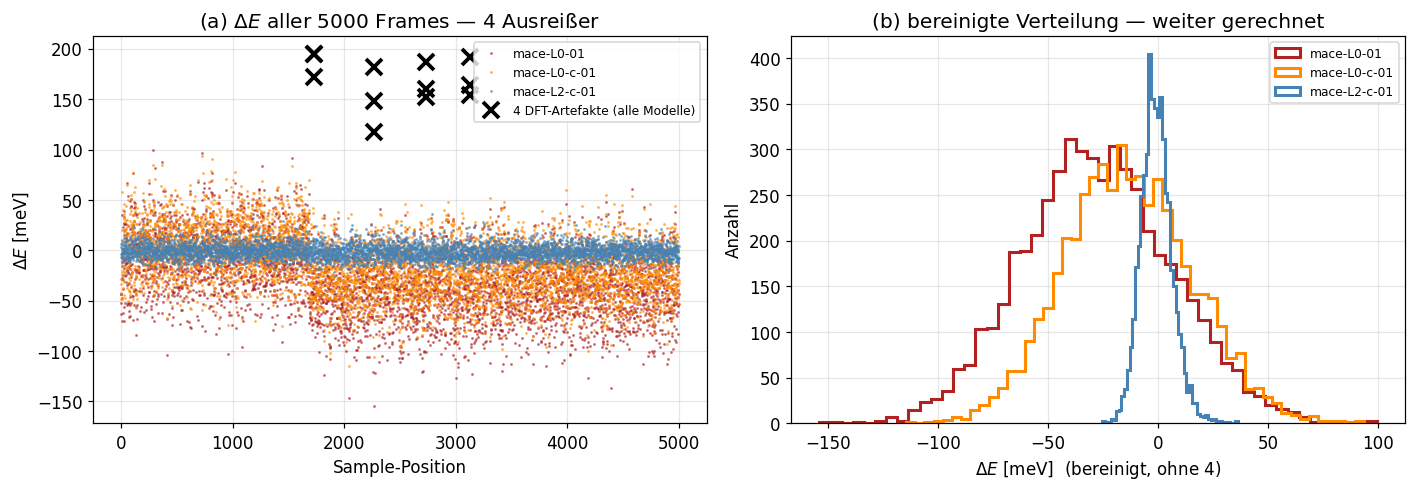

In [4]:
# --- Grosser Datensatz n=5000 (dieselben Strukturen fuer alle Modelle) ---
MODELS_FULL = {
    "mace-L0-01":   "single_mace-L0-01_testfull_n5000.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testfull_n5000.npz",
    "mace-L2-c-01": "single_mace-L2-c-01_testfull_n5000.npz",
}
COL_FULL = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}

# --- Vorab: rechnen alle Modelle wirklich auf denselben Strukturen? ----------
# Der Vergleich setzt es voraus, der Code sichert es nirgends ab: die L0-Saetze
# entstehen durch SLICING des vollen Caches (make_subsample.py), der L2-Satz durch
# NEURECHNEN mit compute_full_energies --indices. Zwei Wege, die sich treffen muessen.
# Pruefbar ueber e_dft: die DFT-Energie eines Frames haengt nicht vom MACE-Modell ab,
# also muessen die Arrays BITGLEICH sein. Bei Verschiebung um einen Frame stuende dort
# ein kleiner, aber von null verschiedener Wert.
_ref = next(iter(MODELS_FULL))
_ref_dft = load_energies(CACHE / MODELS_FULL[_ref])[0]
_ref_idx = np.load(CACHE / MODELS_FULL[_ref])["idx"]
for _m in MODELS_FULL:
    _e = load_energies(CACHE / MODELS_FULL[_m])[0]
    assert np.array_equal(_e, _ref_dft), f"{_m}: e_dft weicht von {_ref} ab -> andere Frames!"
    assert np.array_equal(np.load(CACHE / MODELS_FULL[_m])["idx"], _ref_idx), f"{_m}: idx weicht ab!"
print(f"Frame-Identitaet geprueft: alle {len(MODELS_FULL)} Modelle auf denselben "
      f"{_ref_dft.size} Strukturen (e_dft bitgleich, idx identisch)")

# 4 fehlerhafte DFT-Frames ueber die praezise L2-Referenz identifizieren (dE > 0.1 eV,
# klar abgesetzt vom Rest). Gilt fuer ALLE Modelle, da gleiche Strukturen.
_e_dft, _e_l2 = load_energies(CACHE / MODELS_FULL["mace-L2-c-01"])
_dE_l2 = _e_dft - _e_l2
BAD = _dE_l2 > 0.10                                  # Maske ueber die 5000
print(f"{BAD.sum()} Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen "
      f"(verbleibend: {(~BAD).sum()} Frames)\n")

# Beleg: an den 4 Frames liegen ALLE Modelle nahezu gleich weit daneben (-> DFT, nicht Modell)
_dE_alle = {m: np.subtract(*load_energies(CACHE / MODELS_FULL[m])) for m in MODELS_FULL}
_bad_pos = np.where(BAD)[0]
_idx = np.load(CACHE / MODELS_FULL["mace-L2-c-01"])["idx"][_bad_pos]
print("dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:")
print(f"  {'Frame':>7}" + "".join(f"{m:>14}" for m in MODELS_FULL))
for r, fr in enumerate(_idx):
    print(f"  {fr:>7}" + "".join(f"{_dE_alle[m][_bad_pos[r]]:>14.4f}" for m in MODELS_FULL))

def load_full(name, clean=True):
    # e_dft, e_mace des n5000-Satzes; clean=True entfernt die 4 DFT-Artefakte
    e_dft, e_mace = load_energies(CACHE / MODELS_FULL[name])
    m = ~BAD if clean else np.ones(e_dft.size, bool)
    return e_dft[m], e_mace[m]

# --- Ausreisser einmal zeigen ---
import matplotlib.pyplot as plt
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.6))
for m, col in COL_FULL.items():
    ax.plot(np.arange(_dE_alle[m].size), _dE_alle[m] * 1000, ".", ms=2, alpha=0.5,
            color=col, label=m)
for k, m in enumerate(MODELS_FULL):                 # Ausreisser ALLER Modelle markieren
    ax.plot(np.where(BAD)[0], _dE_alle[m][BAD] * 1000, "x", ms=11, mew=2.5, color="k",
            label=f"{BAD.sum()} DFT-Artefakte (alle Modelle)" if k == 0 else None)
ax.set_xlabel("Sample-Position"); ax.set_ylabel("$\\Delta E$ [meV]")
ax.set_title("(a) $\\Delta E$ aller 5000 Frames — 4 Ausreißer"); ax.legend(fontsize=8)
ax.grid(alpha=0.3)
for m, col in COL_FULL.items():
    bx.hist(_dE_alle[m][~BAD] * 1000, bins=50, histtype="step", lw=2, color=col, label=m)
bx.set_xlabel("$\\Delta E$ [meV]  (bereinigt, ohne 4)"); bx.set_ylabel("Anzahl")
bx.set_title("(b) bereinigte Verteilung — weiter gerechnet"); bx.legend(fontsize=8)
bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a id="1"></a>
## 1. Fragestellung und Überblick

### 1.1 Der Reweighting-Kontext

Eine MD auf einem MACE-Potential erzeugt Konfigurationen $R_i$. Thermodynamische
Mittelwerte, die man eigentlich auf DFT-Niveau haben will, lassen sich aus dieser MD
per **Reweighting** gewinnen:

$$\langle A\rangle_\text{DFT} \;\approx\; \frac{\sum_i A_i\,w_i}{\sum_i w_i},
\qquad w_i = e^{-\beta\,(E_\text{DFT}(R_i)-E_\text{MACE}(R_i))} = e^{-\beta\,\Delta E_i}.$$

Jedes Gewicht $w_i$ verlangt eine DFT-Einzelpunktrechnung $E_\text{DFT}(R_i)$. Das ist
der teure Schritt.

Wie viel die Reweighting-Summe statistisch wert ist, misst die **effektive
Stichprobengröße** (Kish):

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}, \qquad 1 \le N_\text{eff} \le n.$$

Sind alle Gewichte gleich, ist $N_\text{eff}=n$; dominiert ein einzelnes Gewicht, ist
$N_\text{eff}=1$ — man hätte $n$ DFT-Rechnungen bezahlt und statistisch den Wert von
*einer*.

### 1.2 Die Qualitätsfrage

Der statistische Fehler eines reweighteten Mittelwerts skaliert wie
$1/\sqrt{N_\text{eff}}$. Das Verhältnis $N_\text{eff}/n$ ist damit direkt der Faktor, um
den das Reweighting die Fehlerbalken aufbläht:

$$\frac{\sigma_\text{reweighted}}{\sigma_\text{ideal}} = \frac{1}{\sqrt{N_\text{eff}/n}}.$$

Das Effizienzkriterium ist eine Schwelle $R$:

$$\frac{N_\text{eff}}{n} \;\ge\; R \qquad (\text{z.B. } R=0.8 \;\Leftrightarrow\; \text{höchstens }12\,\%\text{ breitere Fehlerbalken}).$$

$R$ ist ein **freier Parameter** des Verfahrens — welchen Wert er haben soll, ist nicht
Gegenstand dieses Notebooks.

Die folgende Abbildung zeigt den Unterschied zwischen einem gutartigen und einem
entarteten Reweighting an den realen Gewichtsverteilungen.

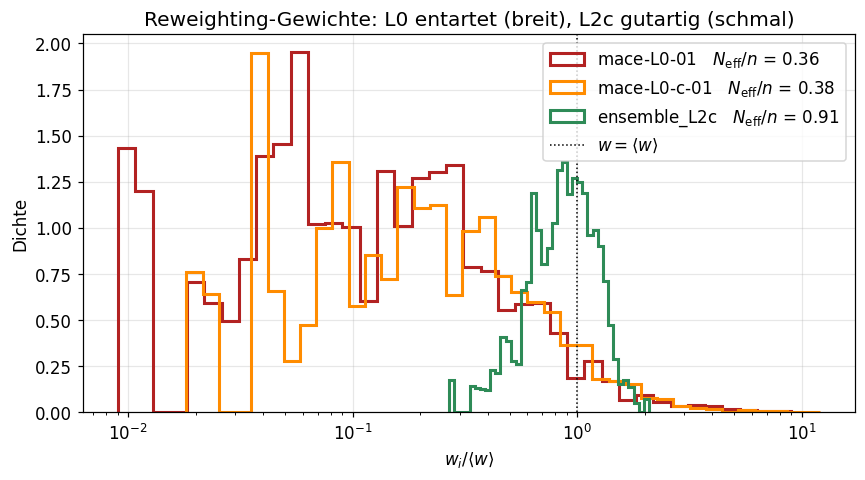

In [5]:
# Motivation: gutartige vs. entartete Gewichtsverteilung (reale Daten)
import numpy as np
import matplotlib.pyplot as plt

show = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
        "ensemble_L2c": "seagreen"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m])
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte: L0 entartet (breit), L2c gutartig (schmal)")
ax.legend(); plt.tight_layout(); plt.show()

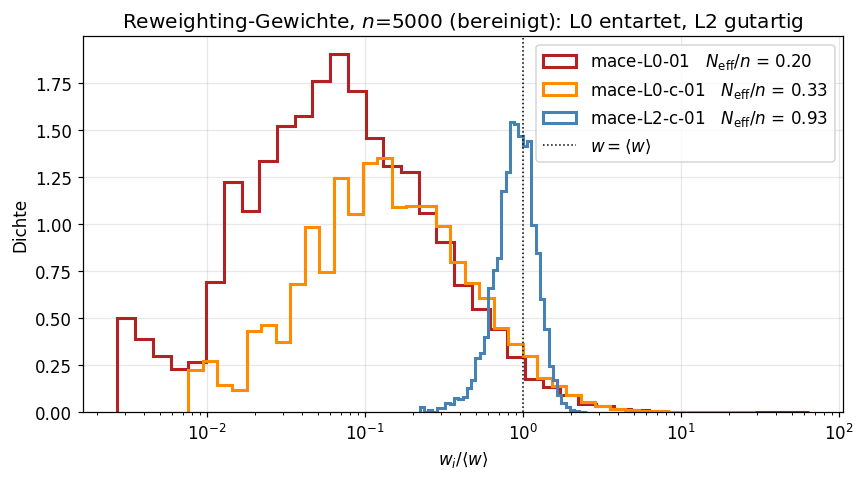

In [6]:
# dasselbe auf dem grossen Satz (n=5000, bereinigt) — SEPARATER Plot neben dem 400er
show_full = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
             "mace-L2-c-01": "steelblue"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show_full.items():
    e_dft, e_mace = load_full(m)                     # bereinigt (ohne die 4 DFT-Artefakte)
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte, $n$=5000 (bereinigt): L0 entartet, L2 gutartig")
ax.legend(); plt.tight_layout(); plt.show()

Die **L0**-Verteilungen sind über mehrere Größenordnungen gespreizt — wenige Frames
tragen fast das ganze Gewicht, $N_\text{eff}/n \approx 0.36$. Die **L2c**-Referenz ist
scharf um 1 konzentriert, $N_\text{eff}/n \approx 0.91$. Für die L0-Modelle ist das
Reweighting also statistisch schwach — und genau das möchte man **früh** erkennen.

### 1.3 Die Kernidee

$N_\text{eff}$ ist eine Funktion der $\Delta E_i$. Deren **Skala** fasst ein einziger
dimensionsloser Parameter zusammen — die Form kommt in §2.3 dazu:

$$\boxed{\,c = \beta\cdot\mathrm{std}(\Delta E)\,}$$

Im Gauß-Grenzfall gilt $N_\text{eff}/n \approx e^{-c^2}$, das Effizienzkriterium wird also
zu einer **Schranke an $c$**:

$$\frac{N_\text{eff}}{n} \ge R \quad\Longleftrightarrow\quad c \le c_\text{max}.$$

Der Gauß-Fall gibt $c_\text{max}=\sqrt{-\ln R}$; die tatsächlich verwendete Schranke ist
die formkorrigierte aus §2.6, und warum die Gauß-Version dafür nicht genügt, misst §8.2.

$c$ konvergiert schnell mit der Zahl der gerechneten DFT-Punkte $k$. Deshalb steht ein
**FAIL** oft früh fest — das ist die Auszahlung für L0. Ein PASS wird dagegen nie
behauptet (§7.1): die Gewichte braucht man am Ende ohnehin vollständig.

<a id="2"></a>
## 2. Der Formalismus: $c$ und die Kumulantenentwicklung

Ziel dieses Abschnitts: $N_\text{eff}/n$ auf **einen** dimensionslosen Parameter
zurückführen und die dabei gemachten Annahmen exakt benennen. Der Grundgedanke —
$\beta\,\sigma_{\Delta U}$ als Konvergenzmaß eines exponentiellen Mittels — stammt aus
der Freie-Energie-Störungstheorie [Zwanzig 1954] und der Phasenraum-Überlapp-Analyse
[Wu & Kofke 2005]; neu ist hier die systematische Formkorrektur über die Kumulanten.

### 2.1 $N_\text{eff}$ als Momentverhältnis

Die effektive Stichprobengröße [Kish 1965] ist

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}.$$

Teilt man Zähler und Nenner durch $n^2$ bzw. $n$ und nutzt das Gesetz der großen Zahlen,
konvergieren die Stichprobenmittel gegen Erwartungswerte:

$$\frac{N_\text{eff}}{n} = \frac{\bar w^{\,2}}{\overline{w^2}}
\;\xrightarrow[n\to\infty]{}\; \frac{E[w]^2}{E[w^2]}. \tag{2.1}$$

> **Annahme (i):** der Grenzübergang $n\to\infty$. Auf endlich vielen vorliegenden
> Gewichten ist $N_\text{eff}/n = (\sum w)^2/(n\sum w^2)$ dagegen **exakt** — eine reine
> Funktion der Gewichte, ohne Modell. Gleichung (2.1) wird nur zum *Extrapolieren*
> gebraucht.

### 2.2 Der Parameter $c$

Schreibe $\Delta E = \mu + \sigma z$ mit standardisiertem $z$ ($E[z]=0$, $\mathrm{Var}(z)=1$)
und definiere

$$c = \beta\,\sigma = \beta\cdot\mathrm{std}(\Delta E).$$

Jedes Gewicht faktorisiert damit in einen **für alle Frames gleichen** Vorfaktor und einen
frame-abhängigen Rest:

$$w_i = e^{-\beta\Delta E_i}
     = \underbrace{e^{-\beta\mu}}_{\text{konstant in }i}\cdot
       \underbrace{e^{-c z_i}}_{=\,v_i,\ \text{trägt Index }i}. \tag{2.2}$$

**Der Offset kürzt sich schon in der endlichen Summenform heraus** — ohne Erwartungswert,
ohne Grenzübergang. In die Kish-Formel eingesetzt:

$$\frac{N_\text{eff}}{n}
= \frac{\left(\sum_i w_i\right)^2}{n\sum_i w_i^2}
= \frac{\left(\sum_i e^{-\beta\mu}\,v_i\right)^2}{n\sum_i e^{-2\beta\mu}\,v_i^2}.$$

Weil $e^{-\beta\mu}$ **nicht von $i$ abhängt**, ist es in jedem Summanden derselbe Faktor
und lässt sich vor die Summe ziehen; $v_i=e^{-cz_i}$ dagegen ist für jeden Frame anders und
bleibt mit seinem Index **in** der Summe:

$$= \frac{\big(e^{-\beta\mu}\big)^2\left(\sum_i v_i\right)^2}{e^{-2\beta\mu}\;n\sum_i v_i^2}
= \frac{e^{-2\beta\mu}}{e^{-2\beta\mu}}\cdot\frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}
= \frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}.$$

Der Faktor $e^{-2\beta\mu}$ steht identisch in Zähler und Nenner und fällt weg — **exakt,
für jede endliche Stichprobe, annahmefrei.**

**Prinzip: Skaleninvarianz.** Multipliziert man alle Gewichte mit derselben Konstante
$\lambda$, ändert sich

$$\frac{\big(\sum_i \lambda w_i\big)^2}{\sum_i (\lambda w_i)^2}
= \frac{\lambda^2\big(\sum_i w_i\big)^2}{\lambda^2\sum_i w_i^2}
= \frac{\big(\sum_i w_i\big)^2}{\sum_i w_i^2}$$

nicht — $\lambda^2$ kürzt sich stets. Ein additiver Energie-Offset ist genau so ein Faktor
($\lambda=e^{-\beta\mu}$) und damit für $N_\text{eff}$ unsichtbar. Dasselbe Argument gilt
für den Variationskoeffizienten $\mathrm{CV}=\mathrm{std}(w)/\langle w\rangle$ und den
Tail-Index $\hat k$.

**Im Grenzwert** $n\to\infty$ (Gl. 2.1) werden die Summenmittel zu Erwartungswerten der
standardisierten Variable:

$$\frac{N_\text{eff}}{n} \;\xrightarrow[n\to\infty]{}\; \frac{E[e^{-c z}]^2}{E[e^{-2c z}]}. \tag{2.3}$$

$N_\text{eff}/n$ hängt also nur von der **Form** der Verteilung (über $z$) und der
**Skala** $c$ ab, nicht vom Mittelwert. Dass genau **ein** Parameter $c$ übrig bleibt,
erzwingt schon die Dimensionsanalyse ($\beta\Delta E$ ist dimensionslos).

### 2.3 Die kumulantenerzeugende Funktion

**Warum dieses Werkzeug.** Der Ausdruck (2.3) enthält nur noch Größen der Form
$E[e^{t z}]$ — das ist die **momenterzeugende Funktion** (MGF) $M(t)=E[e^{t z}]$,
ausgewertet an $t=-c$ und $t=-2c$. Ihr Logarithmus,

$$K(t) = \log M(t) = \log E[e^{t z}],$$

heißt **kumulantenerzeugende Funktion** (CGF). Der Logarithmus ist der entscheidende
Schritt: er verwandelt das Verhältnis von Momenten in (2.3) in eine **Differenz**, und
seine Taylor-Koeffizienten sind gerade die Zahlen, die die Form der Verteilung beschreiben.

**Kumulanten statt Momente.** Entwickelt man $K$ um $t=0$,

$$K(t) = \sum_{m\ge 1}\frac{\kappa_m}{m!}\,t^m,$$

so sind die Koeffizienten $\kappa_m$ die **Kumulanten** von $z$ — nicht die (Roh-)Momente.
Die niedrigsten hängen mit den zentralen Momenten zusammen:

$$\kappa_1 = E[z], \quad \kappa_2 = \mathrm{Var}(z), \quad
  \kappa_3 = E[(z-\bar z)^3], \quad \kappa_4 = E[(z-\bar z)^4] - 3\,\kappa_2^2.$$

Für die **standardisierte** Variable $z$ (Mittel 0, Varianz 1, §2.2) wird das besonders
einfach:

$$\kappa_1 = 0,\quad \kappa_2 = 1,\quad \kappa_3 = \gamma_1\ (\text{Schiefe}),\quad
  \kappa_4 = \gamma_2\ (\text{Exzess-Kurtosis}),$$

also

$$K(t) = \tfrac{1}{2}t^2 + \tfrac{\gamma_1}{6}t^3 + \tfrac{\gamma_2}{24}t^4 + \dots$$

Entscheidend daran: für eine **Normalverteilung** sind alle $\kappa_m$ mit $m\ge3$ exakt
null, also $K(t)=\tfrac12 t^2$. Jede Abweichung von Gauß steckt damit ausschließlich in
$\gamma_1,\gamma_2,\dots$ — das ist der Grund, warum der Gauß-Fall gleich nur $-c^2$
liefert (§2.4).

**Einsetzen in (2.3).** Aus der Definition $K(t)=\log E[e^{t z}]$ folgt unmittelbar
$E[e^{t z}] = e^{K(t)}$. An den beiden benötigten Stellen:

$$E[e^{-c z}] = e^{K(-c)}, \qquad E[e^{-2c z}] = e^{K(-2c)}.$$

Damit wird das Verhältnis (2.3) zu einer Differenz von CGF-Werten — der Logarithmus macht
aus dem Quadrat einen Faktor 2 und aus dem Bruch ein Minuszeichen:

$$\log\frac{N_\text{eff}}{n} = \log\frac{E[e^{-c z}]^2}{E[e^{-2c z}]}
= 2\,K(-c) - K(-2c). \tag{2.4}$$

Dieser Ausdruck ist **exakt** — keine Näherung, keine Gauß-Annahme —, solange $K(-c)$ und
$K(-2c)$ **existieren**, d.h. $E[e^{-c z}]$ und $E[e^{-2c z}]$ (äquivalent $E[w]$ und
$E[w^2]$) endlich sind. Genau diese Existenz führt §7.2 als $\hat k$-Gate mit (§3.2).

### 2.4 Die Entwicklung und der Gauß-Term

Setzt man die Reihe für $K$ in (2.4) ein, so heben sich Zähler- und Nenner-Offset und man
erhält mit $(-2c)^m = (-1)^m 2^m c^m$:

$$\log\frac{N_\text{eff}}{n}
= \sum_{m\ge 2}\frac{\kappa_m}{m!}\,(-1)^m\,(2 - 2^m)\,c^m
= -c^2 + \gamma_1 c^3 - \tfrac{7}{12}\gamma_2 c^4 + O(c^5). \tag{2.5}$$

(Man prüfe die Vorfaktoren: $m=2$ gibt $(2-4)/2!=-1$; $m=3$ gibt $-(2-8)/3!=+1$; $m=4$
gibt $(2-16)/4!=-7/12$.)

**Gauß-Grenzfall.** Behält man nur $m=2$, so ist

$$\frac{N_\text{eff}}{n} \approx e^{-c^2}. \tag{2.6}$$

Für normalverteiltes $\Delta E$ ist (2.6) exakt (alle höheren $\kappa_m=0$). Das ist genau
die Kenngröße $\beta\sigma_{\Delta U}$ der FEP-Konvergenz [Zwanzig 1954] und äquivalent zu
`predicted_neff_gauss` im Code, da $c^2 = \beta^2\mathrm{Var}(\Delta E)$.

### 2.5 Konvergenz — der effektive Parameter ist $2c$

In (2.4) wird $K$ auch an $t=-2c$ ausgewertet. Der $m$-te Term skaliert daher wie
$\sim (2c)^m/m!$, nicht $c^m/m!$ — **der effektive Entwicklungsparameter ist $2c$**. Eine
brauchbare Restabschätzung ist

$$R_5 \approx \frac{(2c)^5}{5!}. \tag{2.7}$$

> **Annahme (ii) — A1 (§3.1):** die Reihe (2.5) konvergiert bei diesem $c$. Prüfbar über (2.7):
> ist $R_5\ll 1$, trägt die Entwicklung; ist $R_5=O(1)$, ist sie wertlos, und man nimmt
> den **exakten** Kish-Wert (der immer existiert, solange $E[w^2]<\infty$).

Die folgende Zelle prüft das an den realen Daten. Hier wird als Schwellwert R = 0,05 verwendet. Desweiteren divergiert die Reihe trivial mit c < 1. 

In [7]:
# Verifikation der Entwicklung (2.5) gegen den exakten Kish-Wert — 400 und 5000 getrennt
import numpy as np
from math import factorial

def expansion_terms(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c  = beta * s
    g1 = float((u**3).mean() / s**3)
    g2 = float((u**4).mean() / s**4 - 3.0)
    kish  = effective_sample_size(reweighting_weights(e_dft, e_mace, beta)) / dE.size
    gauss = np.exp(-c**2)                                  # (2.6), nur -c^2
    three = np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4)         # (2.5), 3 Terme
    R5    = (2*c)**5 / factorial(5)                        # (2.7)
    return c, g1, g2, kish, gauss, three, R5

def print_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'gamma1':>8}{'Kish':>8}{'Gauss':>8}"
          f"{'3-Term':>8}{'Rest 2c^5/5!':>14}{'  A1?':>7}")
    print("-" * 74)
    for m, (e_dft, e_mace) in items:
        c, g1, g2, kish, ga, th, R5 = expansion_terms(e_dft, e_mace)
        ok = "traegt" if R5 < 0.05 else "DIVERGENT" # schwelle für rest als 0,05 definiert 
        print(f"{m:<14}{c:>7.3f}{g1:>+8.3f}{kish:>8.3f}{ga:>8.3f}"
              f"{th:>8.3f}{R5:>14.3f}   {ok}")

print_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in MODELS])
print()
print_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])

n = 400  (testbig):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A1?
--------------------------------------------------------------------------
mace-L0-01      1.238  +0.247   0.361   0.216   0.304         0.774   DIVERGENT
mace-L0-c-01    1.079  +0.207   0.382   0.312   0.362         0.391   DIVERGENT
ensemble_L2c    0.327  +0.501   0.912   0.899   0.912         0.001   traegt
mace-L2-c-01    0.335  +0.413   0.907   0.894   0.907         0.001   traegt

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A1?
--------------------------------------------------------------------------
mace-L0-01      1.340  +0.090   0.196   0.166   0.228         1.152   DIVERGENT
mace-L0-c-01    1.146  +0.127   0.327   0.269   0.347         0.527   DIVERGENT
mace-L2-c-01    0.283  +0.422   0.929   0.923   0.929         0.000   traegt


**Lesart.** Für die **L2c**-Referenz ($c=0.33$) ist der Rest $\approx 0.001$: die
Entwicklung trägt, die 3-Term-Prognose trifft den exakten Kish-Wert auf $<0.1\,\%$. Für
die **L0**-Modelle ($c\approx1.1$–$1.2$) ist der Rest $0.4$–$0.8$: die Reihe divergiert.

Das ist **kein Problem für die Entscheidung** (§7): das FAIL-Urteil hängt an $c$ welches in der Realität immer unter dem Wert 1 liegt. Damit muss nur gegen eine definierte Schwelle für das Restglied geprüft werden.

### 2.6 Die Entscheidungsschranke für $c$

Das Effizienzkriterium $N_\text{eff}/n \ge R$ lässt sich mit (2.4)/(2.5) direkt in eine
**obere Schranke an $c$** übersetzen.

**Gauß-Fall.** Mit $N_\text{eff}/n \approx e^{-c^2}$:

$$e^{-c^2} \ge R
\;\Longleftrightarrow\; -c^2 \ge \ln R
\;\Longleftrightarrow\; c^2 \le -\ln R
\;\Longleftrightarrow\; c \le c_\text{max} = \sqrt{-\ln R}. \tag{2.8}$$

($\ln R < 0$ für $R<1$, die Wurzel ist also reell.) Für $R=0.8$ ist $c_\text{max}=0.472$.

**Mit Formkorrektur.** Aus der vollen Entwicklung (2.5), $\log(N_\text{eff}/n) =
-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4$, wird das Kriterium $\log(N_\text{eff}/n)\ge\ln R$
zu einer **Quartik**:

$$c^2 - \gamma_1 c^3 + \tfrac{7}{12}\gamma_2 c^4 \;\le\; -\ln R. \tag{2.9}$$

Die kleinste positive Lösung $c_\text{max}$ findet man numerisch mit np.roots. Die gültigkeitsgrenze wird hier definiert druch R5 (Restglied der Kumulantenreihe) < 0,05.

In [ ]:
# Verifikation der Schranke c_max (Gauss vs. exakte Quartik)
import numpy as np
from uq_mace.screening import (
    C_VALID, R5_TOL, cmax_gauss, cmax_skew, diagnose)

e_dft, e_mace = load_energies(CACHE / MODELS["ensemble_L2c"])
dE = e_dft - e_mace
s = dE.std(ddof=1); u = dE - dE.mean()
g1 = float((u**3).mean() / s**3); g2 = float((u**4).mean() / s**4 - 3.0)

rest_term = lambda c: (2*c)**5 / 120.0           # Restglied an einer Stelle c

print(f"gamma1 = {g1:+.3f},  gamma2 = {g2:+.3f}   "
      f"(Gueltigkeitsgrenze C_VALID = {C_VALID:.4f})\n")

#Tabelle print - Vergleich von Gauß und Quaternik 
print(f"{'R':>5}{'c_max Gauss':>13}{'c_max exakt':>13}{'R5(c_max)':>12}")
for R_test in (0.7, 0.8, 0.9):          # NICHT R -- das ist ab §7.1 die globale
    ce = cmax_skew(R_test, g1, g2)      # Effizienzschwelle
    print(f"{R_test:>5.1f}{cmax_gauss(R_test):>13.3f}{ce:>13.3f}{rest_term(ce):>12.3f}")

# Voraussetzungen pruefen (Eindeutigkeit, N_eff <= n, A2-Restglied), fuer jedes R
# der Tabelle und mit derselben Toleranz wie C_VALID. Keine Ausgabe = alles gut.
for R_test in (0.7, 0.8, 0.9):
    for m in diagnose(R_test, g1, g2, rem_tol=R5_TOL):
        print(f"\n!! R={R_test}: {m}")

gamma1 = +0.501,  gamma2 = +0.390   (Gueltigkeitsgrenze C_VALID = 0.7155)

    R  c_max Gauss  c_max exakt   R5(c_max)
  0.7        0.597        0.683       0.040
  0.8        0.472        0.529       0.011
  0.9        0.325        0.352       0.001


In [9]:
# --- Test: findet cmax_skew wirklich die kleinste positive Wurzel? -----------
# Die Pruefungen liegen als Datei vor und laufen hier unveraendert. Referenz ist
# nie ein zweites Nullstellenverfahren, sondern
#   * die geschlossene Form sqrt(-ln R) im Gauss-Grenzfall,
#   * analytisch konstruierte Wurzeln: zu c* und gamma2 wird gamma1 so
#     zurueckgerechnet, dass f(c*) = 0 exakt gilt -- die richtige Antwort ist
#     damit vorab bekannt, und ein separater Test bestaetigt, dass c* auch die
#     KLEINSTE Wurzel ist,
#   * die Rueckrechnung exp(log_neff_ratio(c_max, g1, g2)) == R,
#   * der erste Vorzeichenwechsel auf einem Gitter mit 200 001 Punkten -- die
#     einzige Pruefung, die numpy.roots gar nicht benutzt.
import pytest

sys.modules.pop("test_screening", None)      # sonst nimmt pytest beim zweiten
                                             # Lauf das gecachte Modul
rc = pytest.main(["-q", "--no-header", "-p", "no:cacheprovider",
                  str(ROOT / "tests" / "test_screening.py")])
print("\nalle Tests bestanden" if rc == 0 else f"\n!! pytest exit code {rc}")

........................................................................ [ 48%]
........................................................................ [ 96%]
.....                                                                    [100%]
149 passed in 18.86s

alle Tests bestanden


**Welche der beiden Schranken die Regel nimmt:**
Es wird die Schranke genommen welche aus der Quaternik bestimmt wird, da diese genauer ist, da sie mehr Terme der Kumulantenentwicklung beinhaltet.

### 2.7 Literatureinordnung

Der $c$-Formalismus ist **nicht neu**, sondern die auf den Modellfehler übertragene Form
etablierter Kriterien:

- **[Zwanzig 1954]** R. W. Zwanzig, *J. Chem. Phys.* **22**, 1420 — Freie-Energie-
  Störungstheorie; $\beta\sigma_{\Delta U}$ als Konvergenzmaß des exponentiellen Mittels.
- **[Kish 1965]** L. Kish, *Survey Sampling*, Wiley — die effektive Stichprobengröße
  $N_\text{eff}=(\sum w)^2/\sum w^2$.
- **[Wu & Kofke 2005]** D. Wu & D. A. Kofke, *J. Chem. Phys.* **123**, 054103 & 084109 —
  Phasenraum-Überlapp, Bias-Maß über $\sigma_{\Delta U}$, **explizit unter Gauß-Annahme**
  (genau die Lücke, die der $\gamma_1 c^3$-Term schließt).
- **[Kofke 2002]** D. A. Kofke, *J. Chem. Phys.* **117**, 6911 — Akzeptanzrate im Replica
  Exchange aus dem Energieverteilungs-Überlapp; strukturell dieselbe Bedingung
  $c\le c_\text{max}$.
- **[Vehtari et al. 2024]** A. Vehtari, D. Simpson, A. Gelman, Y. Yao, J. Gabry, *JMLR*
  **25** — Pareto-Smoothed Importance Sampling; der Tail-Index $\hat k$ (§8).
- **[Ferrenberg & Swendsen 1989]** *Phys. Rev. Lett.* **63**, 1195 — Histogramm-
  Reweighting; Extrapolationsbereich schrumpft wie $1/\sqrt N$.

*Numerisches Werkzeug:* **[Brent 1973]** R. P. Brent, *Algorithms for Minimization without
Derivatives*, Prentice-Hall (Kap. 4) — das in §2.6 verwendete Nullstellenverfahren
`scipy.optimize.brentq` (Bisektion, abgesichert mit Sekante und inverser quadratischer
Interpolation).

**Vermutlich neu — im Projekt entstanden und *nicht* gegen Literatur geprüft:**
$\gamma_1 c^3$ als quantitatives Gültigkeitskriterium des Gauß-$N_\text{eff}$-Prädiktors.
Die Bausteine sind Standard; vor einer Neuheitsbehauptung im Bericht gezielt
nachrecherchieren.

<a id="3"></a>
## 3. Die zwei Annahmen (A1–A2)

Der Kern des Verfahrens ist **exakt**: $N_\text{eff}/n = (\sum_i w_i)^2/(n\sum_i w_i^2)$ ist
eine Funktion der Gewichte, kein Modell (§2.1). Der Workflow ist für die **iterative
Schätzung auf dem Produktionsstrom selbst** gebaut: die $\Delta E$-Frames sind Teil der
laufenden L0-MD.

Damit ruht das Verfahren auf **genau zwei** Annahmen:

| | Annahme | Charakter | wo behandelt |
|---|---|---|---|
| **A1** | die Kumulantenreihe konvergiert bei diesem $c$ | prüfbar über den Restterm | §2.5, §3.1 |
| **A2** | zwei Momente von $\Delta E$ existieren: $E[\Delta E^4]<\infty$ (polynomial) und $E[e^{-2\beta\Delta E}]<\infty$ (exponentiell) | Eigenschaft der Verteilung, an endlichem $k$ nicht beweisbar → überwachen | §3.2, §7.2 |

### 3.1 A1 — Konvergenz der Kumulantenreihe

Die Prognose $N_\text{eff}/n$ **aus $c$** nutzt die Entwicklung (2.5). Sie konvergiert nur,
wenn $2c$ innerhalb des Konvergenzradius der CGF liegt (§2.5) — prüfbar über den Restterm
$R_5\approx(2c)^5/5!$.


**Bricht A1, ist das kein Beinbruch.** Auf vorhandenen Gewichten ist der Kish-Wert exakt und
annahmefrei (§2.1) — die Reihe wird nur zum *Extrapolieren* aus $c$ gebraucht. Und die
**Entscheidung** (§7) hängt ohnehin nur an $c$ gegen die Schwelle, nicht am genauen
$N_\text{eff}$-Wert.

### 3.2 A2 — Existenz zweier Momente von $\Delta E$

Beide Bedingungen sind Aussagen über $\Delta E$ — aber von **verschiedenem Typ**, und das
ist der Grund, warum keine aus der anderen folgt.

**(i) Ein polynomiales Moment: $E[\Delta E^4]<\infty$ — für die Bandbreite.** Der
Standardfehler der Entscheidungsgröße ist $\mathrm{SE}(c)/c=\sqrt{(\gamma_2+2)/4k}$ (§6.1).
Ohne viertes Moment existiert $\gamma_2$ nicht und das Band um $c$ ist bedeutungslos. Diese
Bedingung bindet **beide** Flanken, aber nur mild.

**(ii) Ein exponentielles Moment: $E[e^{-2\beta\Delta E}]<\infty$ — damit das Kriterium
etwas bedeutet.** Die Kette $c\le c_\text{max} \iff N_\text{eff}/n\ge R$ ruht auf
$\log(N_\text{eff}/n)=2K(-c)-K(-2c)$ (§2.3). Wegen $w=e^{-\beta\mu}e^{-cz}$ ist

$$K(-c)\ \text{existiert} \iff E[w]<\infty, \qquad
  K(-2c)\ \text{existiert} \iff E[w^2]<\infty,$$

es werden also **beide** $w$-Momente gebraucht. Die erste Bedingung folgt aber aus der
zweiten: für nichtnegatives $w$ ist $(E[w])^2\le E[w^2]$ (Cauchy-Schwarz), ein endliches
zweites Moment erzwingt also ein endliches erstes. Übrig bleibt $E[w^2]=E[e^{-2\beta\Delta E}]<\infty$. Diese Bedingung bindet **nur die linke
Flanke** von $\Delta E$ — Strukturen, die MACE zu günstig einschätzt —, diese aber scharf:
sie muss schneller abfallen, als $e^{-2\beta\Delta E}$ wächst. Ist sie verletzt, ist die
Herleitung nicht ungenau, sondern **sinnlos**: $N_\text{eff}$ hat dann keinen
Populationsgrenzwert.

**Unabhängig, mit je einem Gegenbeispiel.** Fällt die linke Flanke exponentiell mit Rate
$\lambda\le2\beta$ ab, so sind alle polynomialen Momente endlich, aber $E[w^2]$ divergiert
— (i) ohne (ii). Ist $\Delta E$ nach unten beschränkt, aber rechts schwer (Pareto-Index 3),
so ist $w$ beschränkt und alle $w$-Momente sind endlich, während $E[\Delta E^4]=\infty$ —
(ii) ohne (i).

**Die Diagnose ist $\hat k$.** Für den Tail-Index $k$ einer verallgemeinerten
Pareto-Verteilung existiert das $r$-te Moment genau dann, wenn $k<1/r$:

$$E[w^2]<\infty \iff k<\tfrac12, \qquad E[w^4]<\infty \iff k<\tfrac14 .$$

Die zweite Form braucht man für Fehlerbalken auf $N_\text{eff}$, nicht für die Entscheidung.
$\hat k$ (PSIS) schätzt $k$; das Gate $\hat k<0{,}5$ ist die praktische Form von (ii) und wird in §7.2 mitgeführt.

**Warum das eine Annahme bleibt.** Momentexistenz ist eine Aussage über den **ungesehenen
Rand**. Dass die $k$ beobachteten Gewichte ein endliches Maximum haben, beweist nichts — das
Stichprobenmaximum ist immer endlich, egal wie schwer der Tail ist. Deshalb wird $\hat k$
**mitgeführt**, nicht einmal geprüft.

<a id="4"></a>
## 4. Die Verteilung von $\Delta E$

§2 hat $c,\gamma_1,\gamma_2$ als Formparameter der $\Delta E$-Verteilung *formal*
eingeführt. Hier schauen wir sie **empirisch** an: Wie sieht die Verteilung aus, ist sie
gaußisch, und wie hängt ihre Form mit der Brauchbarkeit des
Gauß-Terms zusammen.

### 4.1 Die $\Delta E$-Verteilung (400 vs. 5000)

Die zentrierten $\Delta E$ (der Offset $\mu$ ist bedeutungslos, §2.2) für **beide** Datensätze
nebeneinander. Man sieht die **Skala**: L0 streut breit ($c\approx1.2$–$1.3$), L2 schmal
($c\approx0.3$). Die **Form** ($\gamma_1,\gamma_2$) steht in den Tabellen — sie ist der
Schlüssel zu 4.2/4.3.

n = 400 (testbig):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.238   +0.247   +0.094         31.14
mace-L0-c-01      1.079   +0.207   +0.140         27.16
ensemble_L2c      0.327   +0.501   +0.390          8.22
mace-L2-c-01      0.335   +0.413   +0.186          8.42

n = 5000 (bereinigt):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.340   +0.090   -0.053         33.72
mace-L0-c-01      1.146   +0.127   -0.062         28.84
mace-L2-c-01      0.283   +0.422   +0.821          7.13


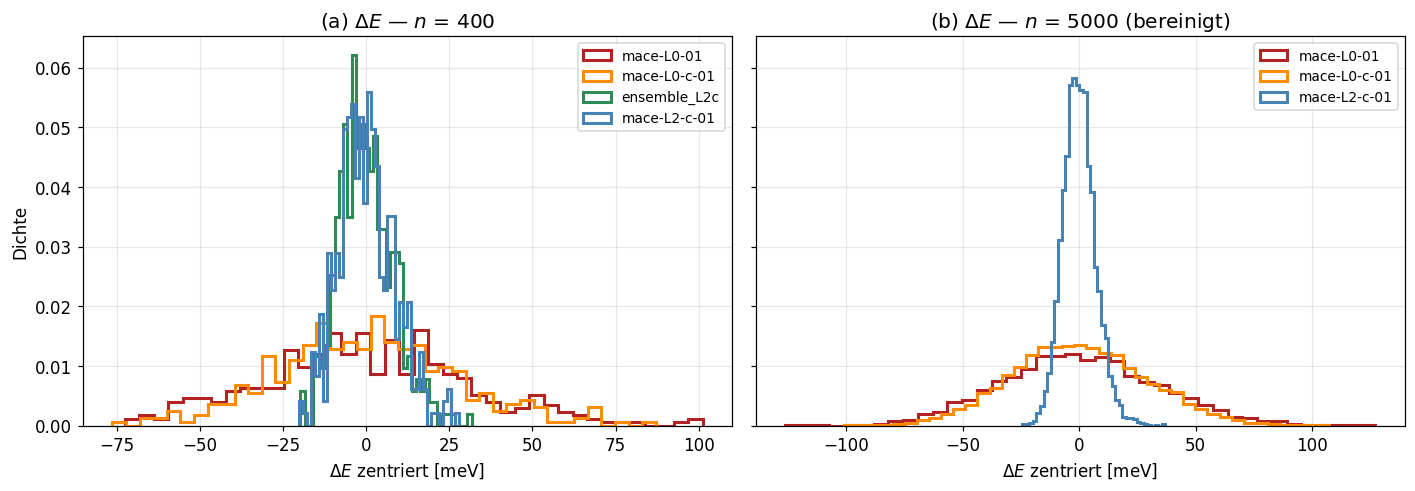

In [10]:
import numpy as np
import matplotlib.pyplot as plt

SHOW_400  = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
             "ensemble_L2c": "seagreen", "mace-L2-c-01": "steelblue"}
SHOW_5000 = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}
SHOW = SHOW_400          # Alias fuer die 400er-Folgeabschnitte (4.2, 4.3)

def moments_row(m, dE):
    s = dE.std(ddof=1); u = dE - dE.mean()
    g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4 - 3)
    print(f"{m:<15}{beta*s:>8.3f}{g1:>+9.3f}{g2:>+9.3f}{s*1000:>14.2f}")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)

print("n = 400 (testbig):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_400.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    moments_row(m, dE)
    a.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

print("\nn = 5000 (bereinigt):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_5000.items():
    e_dft, e_mace = load_full(m); dE = e_dft - e_mace
    moments_row(m, dE)
    b.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

a.set_xlabel("$\\Delta E$ zentriert [meV]"); a.set_ylabel("Dichte")
a.set_title("(a) $\\Delta E$ — $n$ = 400"); a.legend(fontsize=9); a.grid(alpha=0.3)
b.set_xlabel("$\\Delta E$ zentriert [meV]")
b.set_title("(b) $\\Delta E$ — $n$ = 5000 (bereinigt)"); b.legend(fontsize=9); b.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ablesbar.** L2 ist **schmal**, aber (Tabelle) deutlich **rechtsschief** ($\gamma_1\approx0.4$–$0.5$).
Die L0-Modelle sind **breit**, ihre Form aber **näher an der Glocke** ($\gamma_1\approx0.1$–$0.2$).
Merke dir diesen Gegensatz — er ist der Schlüssel zu 4.3. Der große Satz (5000) bestätigt die
Skala und zeigt die L0-Verteilung sogar noch etwas breiter (größeres $c$), also die Entartung
klarer als die 400 Frames.

### 4.2 Ist $\Delta E$ gaußisch? — und warum die Frage in die Irre führt

Der QQ-Plot trägt die empirischen Quantile gegen die einer Normalverteilung auf (Gerade =
gaußisch); der Shapiro-Wilk-Test gibt ein $p$ dazu (klein = Normalität verworfen).

n = 400 (testbig):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9930    6.09e-02 nicht verworfen
mace-L0-c-01        0.9959    3.80e-01 nicht verworfen
ensemble_L2c        0.9850    3.67e-04       verworfen
mace-L2-c-01        0.9884    2.83e-03       verworfen

n = 5000 (bereinigt):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9993    3.97e-02       verworfen
mace-L0-c-01        0.9988    9.62e-04       verworfen
mace-L2-c-01        0.9898    1.47e-18       verworfen


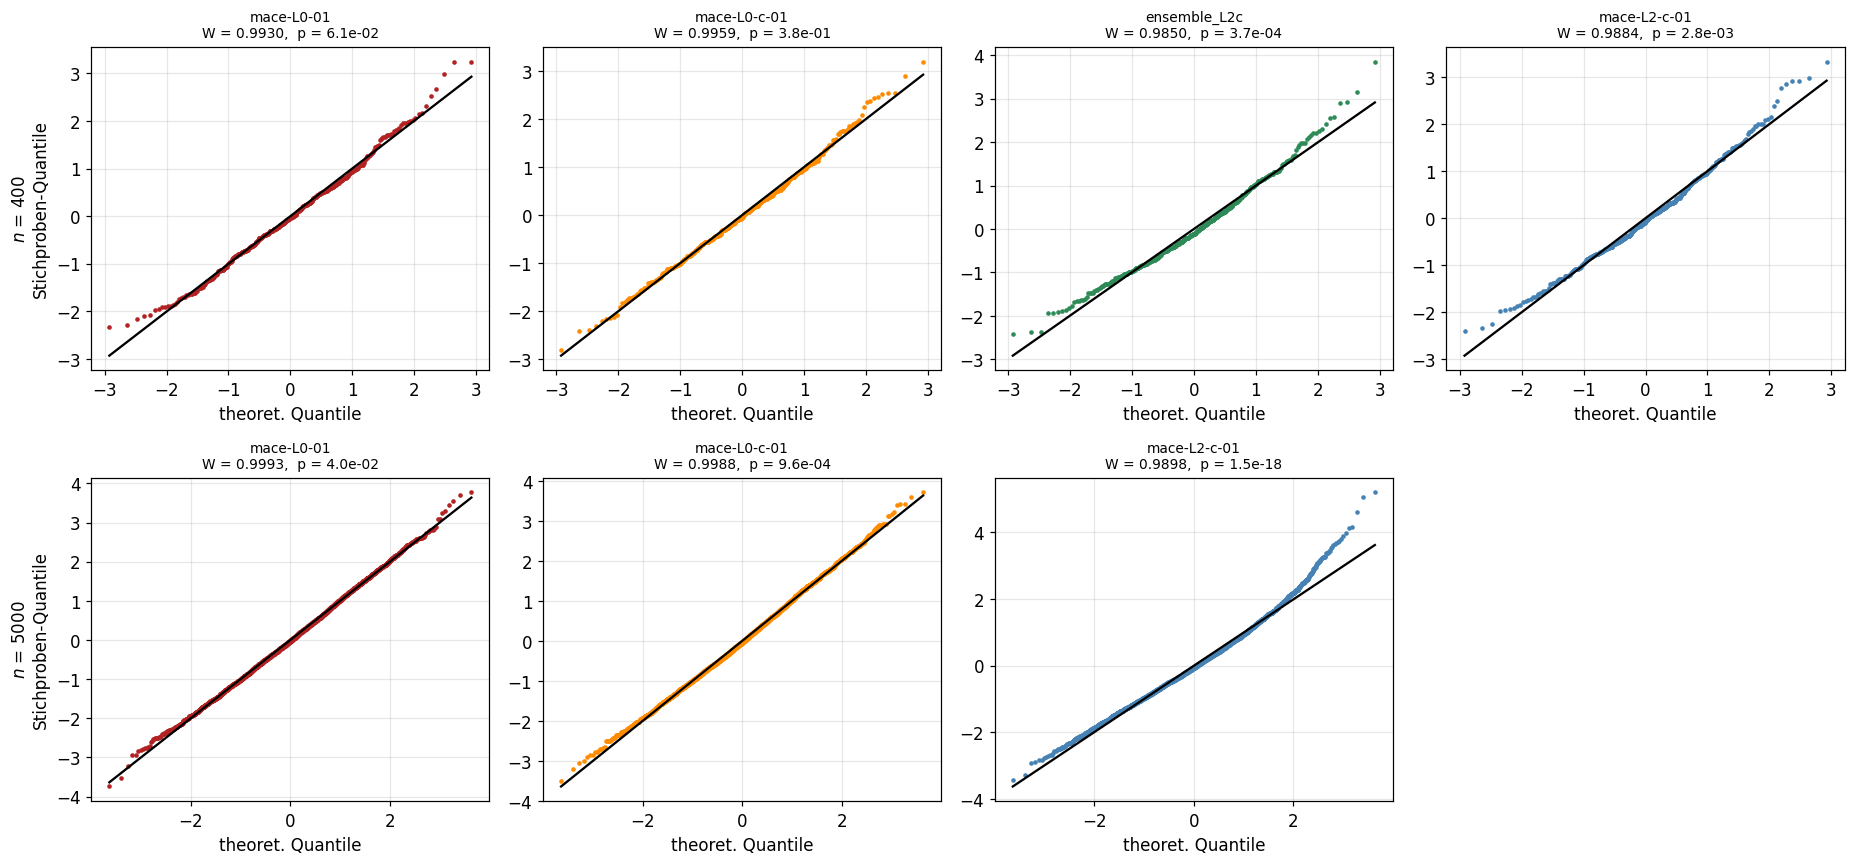

In [11]:
from scipy.stats import shapiro, probplot

def qq_row(axrow, items, loader):
    print(f"{'Modell':<15}{'Shapiro W':>11}{'p-Wert':>12}{'  Normalität':>16}")
    for ax, (m, col) in zip(axrow, items):
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        z = (dE - dE.mean()) / dE.std(ddof=1)
        probplot(z, dist="norm", plot=ax)
        W, pp = shapiro(dE)
        verdict = "verworfen" if pp < 0.05 else "nicht verworfen"
        print(f"{m:<15}{W:>11.4f}{pp:>12.2e}{verdict:>16}")
        ax.set_title(f"{m}\nW = {W:.4f},  p = {pp:.1e}", fontsize=9)
        ax.get_lines()[0].set_color(col); ax.get_lines()[0].set_markersize(2)
        ax.get_lines()[1].set_color("k")
        ax.set_xlabel("theoret. Quantile"); ax.set_ylabel("")

fig, axs = plt.subplots(2, 4, figsize=(17, 8))
print("n = 400 (testbig):")
qq_row(axs[0], list(SHOW_400.items()),  lambda m: load_energies(CACHE / MODELS[m]))
print("\nn = 5000 (bereinigt):")
qq_row(axs[1], list(SHOW_5000.items()), lambda m: load_full(m))
axs[1, 3].axis("off")     # n=5000 hat nur drei Modelle
axs[0, 0].set_ylabel("$n$ = 400\nStichproben-Quantile")
axs[1, 0].set_ylabel("$n$ = 5000\nStichproben-Quantile")
plt.tight_layout(); plt.show()

**Das Paradox — 400 und 5000 direkt gegenübergestellt** (alle L2 = `mace-L2-c-01`):

| Modell | $n$ | $W$ (Nähe zu Gauß) | Shapiro-Urteil | Gauß-Fehler |
|---|---|---|---|---|
| **L2**-c-01 | 400 | 0.988 | verworfen ($p=3\cdot10^{-3}$) | **−1.4 %** |
| | 5000 | 0.990 | verworfen ($p=10^{-18}$) | **−0.7 %** |
| **L0**-c-01 | 400 | 0.996 | *nicht* verworfen ($p=0.38$) | −18.4 % |
| | 5000 | 0.999 | verworfen ($p=10^{-3}$) | −17.7 % |
| **L0**-01 | 400 | 0.993 | *nicht* verworfen ($p=0.06$) | −40.1 % |
| | 5000 | 0.999 | verworfen ($p=0.04$) | −15.3 % |

Zwei Lesarten, beide entlarven den Normalitätstest:

1. **Sein Urteil ist wertlos.** Bei $n=400$ fehlt die Power — L0 wird „bestätigt", L2 verworfen.
   Bei $n=5000$ ist er so mächtig, dass er **alle** verwirft. Keiner der beiden Fälle sagt etwas
   über die Brauchbarkeit des Gauß-Prädiktors.
2. **Sein $W$ ist antikorreliert mit dem, worauf es ankommt.** In *beiden* Datensätzen ist L2 am
   *wenigsten* gaußisch (kleinstes $W$) und hat den *kleinsten* Fehler; die L0-Modelle sind am
   *gaußischsten* ($W\approx0.999$) und haben die *größten*.

Ein Normalitätstest ist hier also nicht nur die falsche Frage, sondern **irreführend**. Der Grund
(4.3): der Gauß-Fehler ist $\gamma_1 c^3$ — Form **mal Skala** —, und die Skala $c$ entscheidet,
nicht die Form.

### 4.3 Kish vs. Gauß — die eigentliche Größe

Wir stellen das **exakte** $N_\text{eff}/n$ (Kish, auf allen Daten, annahmefrei) neben den
**Gauß-Schätzer** $e^{-c^2}$. Die Abweichung ist genau das, was ein Normalitätstest *nicht*
sieht.

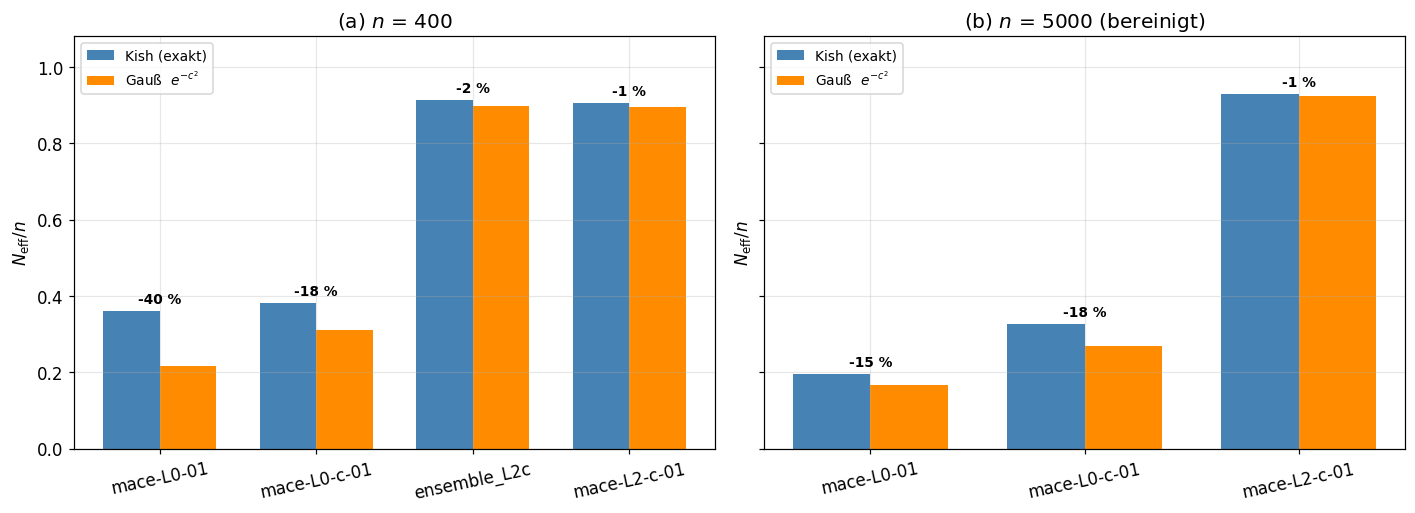

n = 400 (testbig):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.238  +0.247      0.469      0.774   0.361   0.216   -40.1%
mace-L0-c-01     1.079  +0.207      0.260      0.391   0.382   0.312   -18.4%
ensemble_L2c     0.327  +0.501      0.017      0.001   0.912   0.899    -1.5%
mace-L2-c-01     0.335  +0.413      0.016      0.001   0.907   0.894    -1.4%

n = 5000 (bereinigt):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.340  +0.090      0.217      1.152   0.196   0.166   -15.3%
mace-L0-c-01     1.146  +0.127      0.192      0.527   0.327   0.269   -17.7%
mace-L2-c-01     0.283  +0.422      0.010      0.000   0.929   0.923    -0.7%


In [12]:
def kish_gauss_panel(ax, items, loader, title):
    ms = list(items); x = np.arange(len(ms)); wd = 0.36
    kish, gauss, rows = [], [], []
    for m in ms:
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        s = dE.std(ddof=1); u = dE - dE.mean()
        c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
        k = effective_sample_size(reweighting_weights(e_dft, e_mace, beta))/dE.size
        kish.append(k); gauss.append(np.exp(-c**2))
        rows.append((m, c, g1, k, np.exp(-c**2), g1*c**3, (2*c)**5/120))
    ax.bar(x-wd/2, kish, wd, label="Kish (exakt)", color="steelblue")
    ax.bar(x+wd/2, gauss, wd, label="Gauß  $e^{-c^2}$", color="darkorange")
    for i in range(len(ms)):
        ax.text(i, max(kish[i], gauss[i])+0.02, f"{100*(gauss[i]/kish[i]-1):+.0f} %",
                ha="center", fontweight="bold", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=12); ax.set_ylim(0, 1.08)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")
    return rows

def print_decomp(title, rows):
    print(title)
    print(f"{'Modell':<15}{'c':>7}{'gamma1':>8}{'gamma1*c^3':>11}{'(2c)^5/5!':>11}"
          f"{'Kish':>8}{'Gauss':>8}{'Fehler':>9}")
    for m, c, g1, k, ga, t3, R5 in rows:
        print(f"{m:<15}{c:>7.3f}{g1:>+8.3f}{t3:>11.3f}{R5:>11.3f}{k:>8.3f}{ga:>8.3f}"
              f"{100*(ga/k-1):>+8.1f}%")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
rows400  = kish_gauss_panel(a, SHOW_400,  lambda m: load_energies(CACHE / MODELS[m]),
                            "(a) $n$ = 400")
rows5000 = kish_gauss_panel(b, SHOW_5000, lambda m: load_full(m),
                            "(b) $n$ = 5000 (bereinigt)")
plt.tight_layout(); plt.show()

print_decomp("n = 400 (testbig):", rows400); print()
print_decomp("n = 5000 (bereinigt):", rows5000)

**Die Auflösung.** Der Gauß-Fehler hängt nicht davon ab, *wie* gaußisch $\Delta E$ ist,
sondern von $\gamma_1 c^3$ — **Form mal Skala-hoch-drei**. L0 hat sogar die *kleinere* Schiefe
($\gamma_1\approx0.2$ vs. $0.50$), aber sein $c^3$ ist ~50× größer ($1.24^3$ vs. $0.33^3$).
Der Schiefe-Beitrag $\gamma_1 c^3$ ist deshalb bei L0 rund 0.4–0.5, bei L2c nur 0.018 — Faktor
$\sim25$. Ein Normalitätstest misst die **Form**, nicht die $c$-Verstärkung, und geht deshalb
in die Irre. Die richtige Größe ist $\gamma_1 c^3$ (bzw. der Restterm $(2c)^5/5!$) — oder, wenn
man die Zahl braucht, **direkt Kish**.

### 4.4 Was das für L0 bedeutet

Der Gegensatz aus 4.1/4.3 wird jetzt zur Aussage — und beide Datensätze zeigen ihn:

- Bei kleinem $c$ (**L2**, $c\approx0.28$–$0.33$) ist $c^3$ winzig, die Formabweichung wird um
  Faktor $\sim30$–$45$ **gedämpft** — der Gauß-Term trägt, trotz nachgewiesener Nicht-Normalität
  ($\gamma_1 c^3\approx0.01$, Rest $\approx0$). Der Fehler bleibt unter 2 % (400) bzw. 1 % (5000).
- Bei großem $c$ (**L0**, $c\approx1.1$–$1.3$) ist $c^3\approx1.3$–$2.4$ **nicht** mehr gedämpft;
  die Form **dominiert**, und der effektive Entwicklungsparameter $2c\approx2.2$–$2.7$ liegt
  außerhalb des Konvergenzradius (§2.5) — die Reihe **divergiert** (Restterm $(2c)^5/5!\approx
  0.4$–$1.2$, Spalten oben). Der große Satz treibt $c$ sogar noch höher (1.24→1.34) — die
  Divergenz wird also **schärfer**, nicht milder.

**Konsequenz für den Workflow.** Für L0 ist der Gauß-/Kumulanten-*Prädiktor* wertlos — man nimmt
den exakten Kish-Wert (§2.1). Die **Entscheidung** bleibt davon unberührt: sie hängt an $c$
gegen $c_\text{max}$ (§2.6, §7), und $c=\beta\,\mathrm{std}(\Delta E)$ ist selbst dann robust,
wenn die Reihe längst nicht mehr trägt (§6). L0 ist also gerade der Fall, in dem die *Form* die
Prognose sprengt, die *Entscheidung* aber stabil bleibt — auf 400 wie auf 5000 Frames.

<a id="5"></a>
## 5. Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$

§2–§4 haben die Größen einzeln benutzt. Hier stellen wir sie **nebeneinander** und
beantworten die Leitfrage: *Warum reicht $c$ allein nicht — und wie wird aus der Kombination
ein verlässlicher Indikator?* Der Abschnitt schließt mit einem Beweis an den echten Daten.

### 5.1 Die drei Größen und ihre Rollen

| Größe | misst | Rolle | Charakter |
|---|---|---|---|
| $c=\beta\,\mathrm{std}(\Delta E)$ | Breite der $\Delta E$-Verteilung | **Skala / Entscheidung** | schnell, aber allein kein Prädiktor |
| $\hat k$ (PSIS-Tail) | Schwere des Gewichts-Tails | **Existenz-Gate** | ja/nein: existiert $N_\text{eff}$? |
| $N_\text{eff}$ (Kish) | $(\sum w)^2/\sum w^2$ | **exakte Wahrheit** | annahmefrei, nur auf vorhandenen Daten |

Die Werte für die realen Modelle als gemeinsamer Startpunkt:

In [13]:
import numpy as np
from uq_mace.reweighting import psis_khat

FOUR = ["ensemble_L2c", "mace-L2-c-01", "mace-L0-c-01", "mace-L0-01"]
print(f"{'Modell':<15}{'c':>8}{'khat':>9}{'N_eff/n (Kish)':>16}")
for m in FOUR:
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    print(f"{m:<15}{beta*dE.std(ddof=1):>8.3f}{psis_khat(w):>+9.3f}"
          f"{effective_sample_size(w)/dE.size:>16.3f}")

Modell                c     khat  N_eff/n (Kish)
ensemble_L2c      0.327   +0.068           0.912
mace-L2-c-01      0.335   -0.086           0.907
mace-L0-c-01      1.079   +0.416           0.382
mace-L0-01        1.238   +0.050           0.361


### 5.2 Wie die Kombination zum Indikator wird

Der Indikator entsteht in **vier Schichten**, jede schließt eine Lücke, die die vorige offen
lässt:

**Schicht 1 — $c$: die Skala.** $c=\beta\,\mathrm{std}(\Delta E)$ misst die Breite, ist schnell
bestimmt (§6). Bei festem $c$ ist $N_\text{eff}/n$ aber **nicht** bestimmt: es hängt
zusätzlich von der Form ab (§2.3) — $c$ allein gibt nur die Größenordnung.

**Schicht 2 — Form ($\gamma_1,\gamma_2$): macht $c$ zur Prognose.** Die Kumulantenentwicklung
$N_\text{eff}/n = \exp(-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4)$ nutzt Skala **und** Form. Kennt man beides, ist $N_\text{eff}/n$
festgelegt (wo die Reihe konvergiert, §2.5). Hieraus wird die Schranke $c_\text{max}$ berechnet.

**Schicht 3 — $\hat k$: das Existenz-Gate.** Selbst mit $c$ und Form ist alles bedeutungslos,
falls $N_\text{eff}$ gar nicht existiert ($E[w^2]=\infty$). $\hat k<0{,}5$ ist die einzige verfügbare Evidenz dafür,
dass es existiert — beweisen lässt es sich an endlichem $k$ nicht (§3.2). Eine
Vorbedingung unabhängig von $c$ und Form, im Workflow mitgeführt (§7.2).

**Schicht 4 — Kish: der exakte Anker.** Auf den vorhandenen Gewichten ist
$N_\text{eff}/n=(\sum w)^2/(n\sum w^2)$ exakt und annahmefrei — die Wahrheit, gegen die Schicht 2
geprüft wird, und der **Rückfallwert**, wenn die Reihe (großes $c$) versagt.

> **Der Indikator.** Die Entscheidung läuft über $c$ gegen $c_\text{max}$ (§7), abgesichert
> durch das $\hat k$-Gate und, wo nötig, den exakten Kish-Wert. 

### 5.3 Beweis an den echten Daten

Für jedes Modell stellen wir nebeneinander: den Gauß-Schätzer ($c$ **allein**), die
Kumulanten-Prognose ($c$ **+ Form**), und die exakte Kish-Wahrheit — plus das $\hat k$-Gate.
Panel **(a)** zeigt den Testsatz ($n$ = 400), Panel **(b)** den großen Satz
($n$ = 5000, 4 DFT-Artefakte entfernt) im selben Stil.

n = 400  (testbig):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
ensemble_L2c    0.327 +0.068     OK konvergent |     0.899           0.912   0.912
mace-L2-c-01    0.335 -0.086     OK konvergent |     0.894           0.907   0.907
mace-L0-c-01    1.079 +0.416     OK  divergent |     0.312         (0.362)   0.382
mace-L0-01      1.238 +0.050     OK  divergent |     0.216         (0.304)   0.361

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
mace-L0-01      1.340 +0.314     OK  divergent |     0.166         (0.228)   0.196
mace-L0-c-01    1.146 +0.223     OK  divergent |     0.269         (0.347)   0.327
mace-L2-c-01    0.283 +0.024     OK konvergent |     0.923           0.929   0

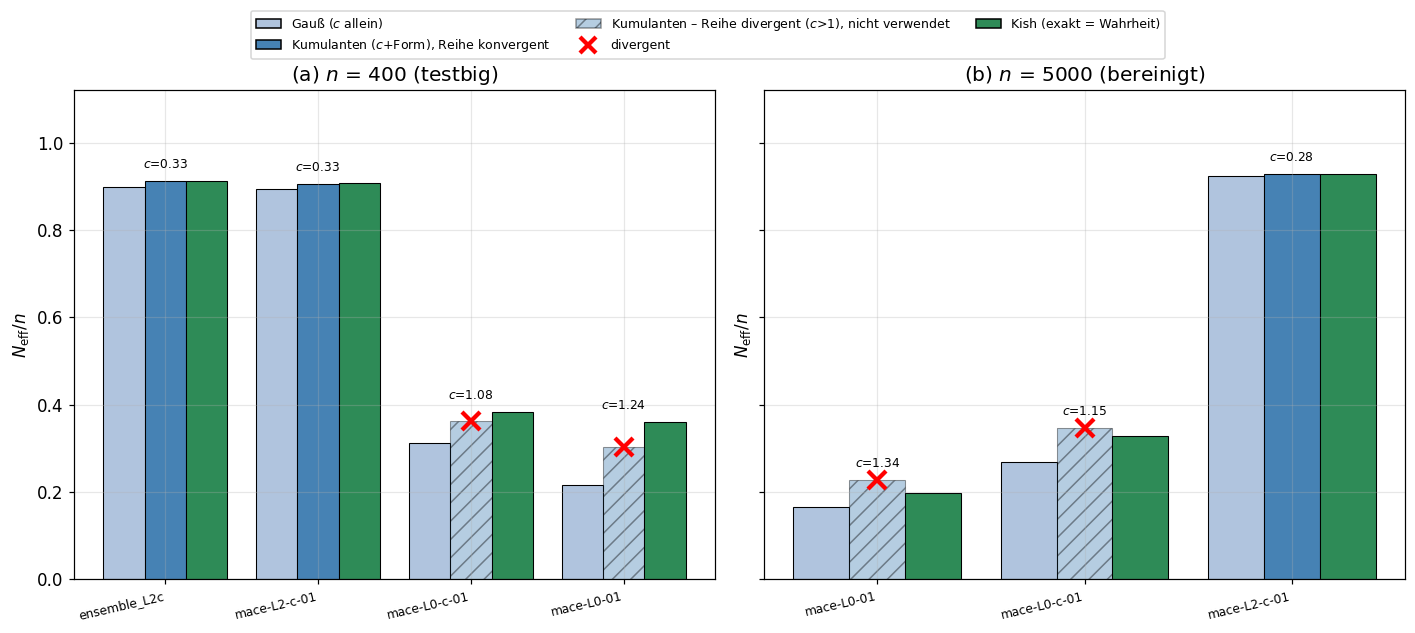

In [14]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def proof_stats(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
    w = reweighting_weights(e_dft, e_mace, beta)
    kish = effective_sample_size(w)/dE.size; kh = psis_khat(w)
    return c, kh, np.exp(-c**2), np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4), kish

def proof_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'khat':>7}{'Gate':>7}{'Reihe':>11} | "
          f"{'Gauß(c)':>9}{'Kumul.(c+Form)':>16}{'Kish':>8}")
    print("-"*92)
    for m, (e_dft, e_mace) in items:
        c, kh, gauss, kumul, kish = proof_stats(e_dft, e_mace)
        gate = "OK" if kh < 0.5 else "FAIL"
        div  = "divergent" if (2*c)**5/120 >= 0.05 else "konvergent"
        # bei Divergenz ist die Kumulanten-Zahl formal ungueltig -> als (…) markiert
        kstr = f"({kumul:.3f})" if div == "divergent" else f"{kumul:.3f}"
        print(f"{m:<14}{c:>7.3f}{kh:>+7.3f}{gate:>7}{div:>11} | "
              f"{gauss:>9.3f}{kstr:>16}{kish:>8.3f}")

proof_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in FOUR])
print()
proof_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])
print("\n(...) = Reihe divergent (c>1), Wert formal ungueltig -> es gilt der exakte Kish-Wert.")

# Drei Balken je Modell: Gauss-Praediktor, Kumulanten-Praediktor, Kish (Wahrheit).
# Divergente Reihe (c>1) -> Kumulanten-Balken schraffiert + rot durchgestrichen (nicht verwendet).
def proof_bars(ax, items, title):
    ms = list(items); x = np.arange(len(ms)); w = 0.27
    for i, m in enumerate(ms):
        c, kh, gauss, kumul, kish = proof_stats(*items[m])
        div = (2*c)**5/120 >= 0.05
        ax.bar(x[i]-w, gauss, w, color="lightsteelblue", edgecolor="k", lw=0.7)
        ax.bar(x[i],   kumul, w, color="steelblue", edgecolor="k", lw=0.7,
               hatch="//" if div else "", alpha=0.4 if div else 1.0)
        ax.bar(x[i]+w, kish,  w, color="seagreen", edgecolor="k", lw=0.7)
        if div:
            ax.plot(x[i], kumul, "x", color="red", ms=12, mew=2.8, zorder=6)
        ax.text(x[i], max(gauss, kumul, kish)+0.03, f"$c$={c:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=13, ha="right", fontsize=8)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_ylim(0, 1.12); ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
proof_bars(a, {m: load_energies(CACHE / MODELS[m]) for m in FOUR}, "(a) $n$ = 400 (testbig)")
proof_bars(b, {m: load_full(m) for m in MODELS_FULL},              "(b) $n$ = 5000 (bereinigt)")
handles = [Patch(fc="lightsteelblue", ec="k", label="Gauß ($c$ allein)"),
           Patch(fc="steelblue", ec="k", label="Kumulanten ($c$+Form), Reihe konvergent"),
           Patch(fc="steelblue", ec="k", hatch="//", alpha=0.4,
                 label="Kumulanten – Reihe divergent ($c$>1), nicht verwendet"),
           Line2D([], [], color="red", marker="x", ls="", ms=11, mew=2.8, label="divergent"),
           Patch(fc="seagreen", ec="k", label="Kish (exakt = Wahrheit)")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=8.2, bbox_to_anchor=(0.5, 1.07))
plt.tight_layout(); plt.show()

**Was der Beweis zeigt** (Panel (a) $n$=400, Panel (b) $n$=5000; je drei Balken pro Modell):

- **$c$ allein (Gauß, hellblau)** trifft für die guten Modelle fast die Kish-Wahrheit, für L0 aber weit daneben (bis $-40\,\%$ bei $n$=400, $-18\,\%$ bei $n$=5000) — die Skala allein genügt nicht.
- **$c$ + Form (Kumulanten, dunkelblau)** ist nur dort gezeichnet, wo die **Reihe konvergiert** ($c<1$, Restglied $(2c)^5/5!<0.05$): für **L2c/L2-c-01** trifft sie die Wahrheit exakt ($<0.1\,\%$ in beiden Sätzen). Für **L0** ist $c\approx1.1$–1.34, die Reihe **divergiert** (§2.5) — der Balken ist deshalb **schraffiert und rot durchgestrichen**: er zeigt nur, *was* die divergente Reihe ausspuckt, wird aber **nicht verwendet**. Dort gilt allein der exakte Kish-Wert (grün, Schicht 4).
- **$\hat k$-Gate** ist bei allen bestanden ($<0.5$), $N_\text{eff}$ existiert also überall. L0-c-01 liegt bei $n$=400 mit $0.42$ nahe an der Grenze; auf dem größeren Satz entspannt sich das auf $0.22$ (innerhalb der Schätzunsicherheit, vgl. die Streuung in §7.2).

Die Rollen bleiben sauber getrennt: bei kleinem $c$ liefert die Reihe die genaue Prognose (hell- und dunkelblau decken den grünen Balken), bei großem $c$ ist sie ungültig und man liest direkt den grünen Kish-Balken. Das **reproduziert sich von 400 auf 5000 Frames** — und **keine der Größen allein leistet es**.

<a id="6"></a>
## 6. Konvergenz der Momente

§5 hat gezeigt: ohne die Form ($\gamma_1,\gamma_2$) ist keine Aussage möglich — sie sind
**essenziell**. Zugleich konvergieren sie **langsam und verzerrt**. Dieser Abschnitt löst die
Spannung auf: Wie schnell konvergieren $c,\gamma_1,\gamma_2$, woher kommen ihre Standardfehler,
und warum ist die langsame Konvergenz für die Entscheidung trotzdem unkritisch.

### 6.1 Woher die Standardfehler kommen

Der Standardfehler von $c=\beta\sigma$ (mit $\sigma=\mathrm{std}(\Delta E)$, §2.2) folgt aus
einer einzigen Beobachtung: **die Stichprobenvarianz ist selbst ein Mittelwert.** Damit ist der
Rest gewöhnliche Fehlerfortpflanzung.

Schreibe den Schätzer $\widehat{\sigma^2}$ als

$$\widehat{\sigma^2} \approx \frac{1}{k}\sum_{i=1}^{k}\underbrace{(\Delta E_i-\mu)^2}_{\equiv\,Y_i},$$

also den Mittelwert von $k$ Zahlen $Y_i=(\Delta E_i-\mu)^2$ mit $E[Y]=\sigma^2$. Für den
Mittelwert von irgendetwas ist die Unsicherheit bekannt:
$\mathrm{Var}(\overline Y)=\mathrm{Var}(Y)/k$ — das ist der Ursprung des $1/k$, dasselbe
Averaging-Argument wie beim Standardfehler des Mittelwerts.

**Schritt 1 — die Varianz von $Y$.** Mit $Y=(\Delta E-\mu)^2$ ist

$$\mathrm{Var}(Y)=E[Y^2]-E[Y]^2=E[(\Delta E-\mu)^4]-\big(E[(\Delta E-\mu)^2]\big)^2=\mu_4-\sigma^4,$$

mit $\mu_4$ dem vierten zentralen Moment. Also

$$\mathrm{Var}(\widehat{\sigma^2})=\frac{\mu_4-\sigma^4}{k}.$$

Anschaulich: die Varianz ist aus *quadrierten* Abweichungen gebaut, ihre Schwankung hängt daher
an *vierten* Potenzen — am vierten Moment. Ausreißer (dicke Flanken) bewegen sie stark.

**Schritt 2 — die Form einsetzen.** Die Exzess-Kurtosis ist $\gamma_2=\mu_4/\sigma^4-3$ (§2.3),
also $\mu_4=(\gamma_2+3)\sigma^4$ und damit $\mu_4-\sigma^4=(\gamma_2+2)\sigma^4$. In
**relativer** Form (teilen durch $\sigma^2$, quadriert also $\sigma^4$):

$$\frac{\mathrm{SE}(\widehat{\sigma^2})}{\sigma^2}=\frac{\sqrt{(\gamma_2+2)\sigma^4/k}}{\sigma^2}=\sqrt{\frac{\gamma_2+2}{k}}.$$

Das $\sigma^4$ kürzt sich weg — die *relative* Präzision der Varianz hängt nur an der Form
($\gamma_2$) und der Stichprobengröße ($k$), nicht an der Skala.

**Schritt 3 — von der Varianz zur Standardabweichung (die Wurzel).** Gebraucht wird
$\sigma=\sqrt{\sigma^2}$. Die Delta-Methode gibt für eine Funktion $g$ den Zusammenhang
$\mathrm{SE}(g(X))\approx|g'|\,\mathrm{SE}(X)$; mit $g(X)=\sqrt X$ und $g'=\tfrac{1}{2\sqrt X}$
wird

$$\frac{\mathrm{SE}(\sqrt X)}{\sqrt X}=\frac{\mathrm{SE}(X)/(2\sqrt X)}{\sqrt X}=\frac12\,\frac{\mathrm{SE}(X)}{X}.$$

Die Wurzel **halbiert den relativen Fehler** (weil $\mathrm{d}\ln\sqrt X=\tfrac12\,\mathrm{d}\ln X$):
ist die Varianz auf ±10 % bekannt, dann $\sigma$ auf ±5 %. Also

$$\frac{\mathrm{SE}(\hat\sigma)}{\sigma}=\frac12\sqrt{\frac{\gamma_2+2}{k}}=\sqrt{\frac{\gamma_2+2}{4k}}.$$

**Schritt 4 — von $\sigma$ zu $c$.** $c=\beta\sigma$ mit der Konstanten $\beta$; eine Konstante
ändert den *relativen* Fehler nicht und kürzt sich in
$\mathrm{SE}(c)/c=\mathrm{SE}(\hat\sigma)/\sigma$ heraus:

$$\boxed{\;\frac{\mathrm{SE}(c)}{c}=\sqrt{\frac{\gamma_2+2}{4k}}\;}$$

Der Grenzfall Gauß ($\gamma_2=0$) gibt $\mathrm{SE}(c)/c=1/\sqrt{2k}$ — die vertraute
$1/\sqrt{k}$-Rate; dicke Flanken ($\gamma_2>0$) vergrößern sie. Die einzigen Näherungen sind „die Varianz ist ein
Mittelwert" (exakt bis auf den bei großem $k$ vernachlässigbaren $(k-1)/k$-Bias) und die
Linearisierung der Wurzel — beides **verteilungsallgemein**, nirgends steckt Normalität drin,
nur ein endliches viertes Moment.

**$\gamma_1,\gamma_2$ — Unsicherheit ausschließlich per Bootstrap.** $\gamma_1$ ist die Schiefe,
$\gamma_2$ die Exzess-Kurtosis von $\Delta E$ (§2.3, §5) — die beiden Formkorrekturen der
Kumulantenentwicklung. Geschlossene Standardfehler gibt es für sie nur unter der Nullhypothese
„$\Delta E$ normalverteilt". $\Delta E$ ist aber nachweislich *nicht* normal (§4); dann hängt die
wahre Varianz von $\gamma_1,\gamma_2$ von noch höheren Momenten ab und ist **größer** als die
Normaltheorie — eine analytische Formel würde die Unsicherheit systematisch unterschätzen.
Deshalb schätzen wir $\mathrm{SE}(\gamma_1)$ und $\mathrm{SE}(\gamma_2)$ **ausschließlich per
Bootstrap** (§6.2), ohne analytische Näherung.

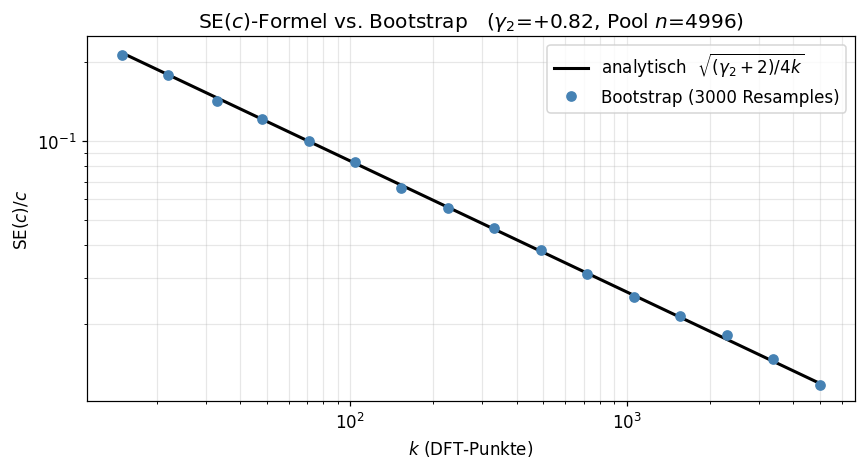

max. Abweichung Bootstrap/analytisch: 3.9 %   (über k = 15…4996)


In [15]:
# Verifikation der SE(c)-Formel gegen den Bootstrap (gut-artiger Pool L2-c-01, n=5000 bereinigt)
import numpy as np
import matplotlib.pyplot as plt

ed_v, em_v = load_full("mace-L2-c-01")                 # bereinigt (ohne die 4 DFT-Artefakte)
dE_v = ed_v - em_v
g2_v = float(((dE_v - dE_v.mean())**4).mean() / dE_v.std(ddof=1)**4 - 3)
c_v  = beta * dE_v.std(ddof=1)

rng = np.random.default_rng(0)
ks_v = np.unique(np.round(np.geomspace(15, dE_v.size, 16)).astype(int))
se_boot, se_ana = [], []
for k in ks_v:
    cb = beta * np.array([dE_v[rng.integers(0, dE_v.size, k)].std(ddof=1) for _ in range(3000)])
    se_boot.append(cb.std(ddof=1) / c_v)               # Bootstrap-SE, relativ
    se_ana.append(np.sqrt((g2_v + 2) / (4 * k)))       # Formel aus 6.1
se_boot, se_ana = np.array(se_boot), np.array(se_ana)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.loglog(ks_v, se_ana,  color="k", lw=2, label=r"analytisch  $\sqrt{(\gamma_2+2)/4k}$")
ax.loglog(ks_v, se_boot, "o", color="steelblue", ms=6, label="Bootstrap (3000 Resamples)")
ax.set_xlabel("$k$ (DFT-Punkte)"); ax.set_ylabel(r"$\mathrm{SE}(c)/c$")
ax.set_title(f"SE($c$)-Formel vs. Bootstrap   ($\\gamma_2$={g2_v:+.2f}, Pool $n$={dE_v.size})")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print(f"max. Abweichung Bootstrap/analytisch: {np.abs(se_boot/se_ana - 1).max()*100:.1f} %"
      f"   (über k = {ks_v.min()}…{ks_v.max()})")

### 6.2 Bootstrap-Konvergenz und Bias

Wir ziehen Bootstrap-Stichproben der Größe $k$ und verfolgen Median und 5–95 %-Band von $c,\gamma_1,\gamma_2$ — **aus den 400 Testframes** (blau, $k$ bis 400) und **aus dem großen Satz** (rot, $k$ bis 5000). Der größere Pool lässt $k$ weiter laufen und zeigt, wie die Bänder über $k=400$ hinaus schrumpfen.

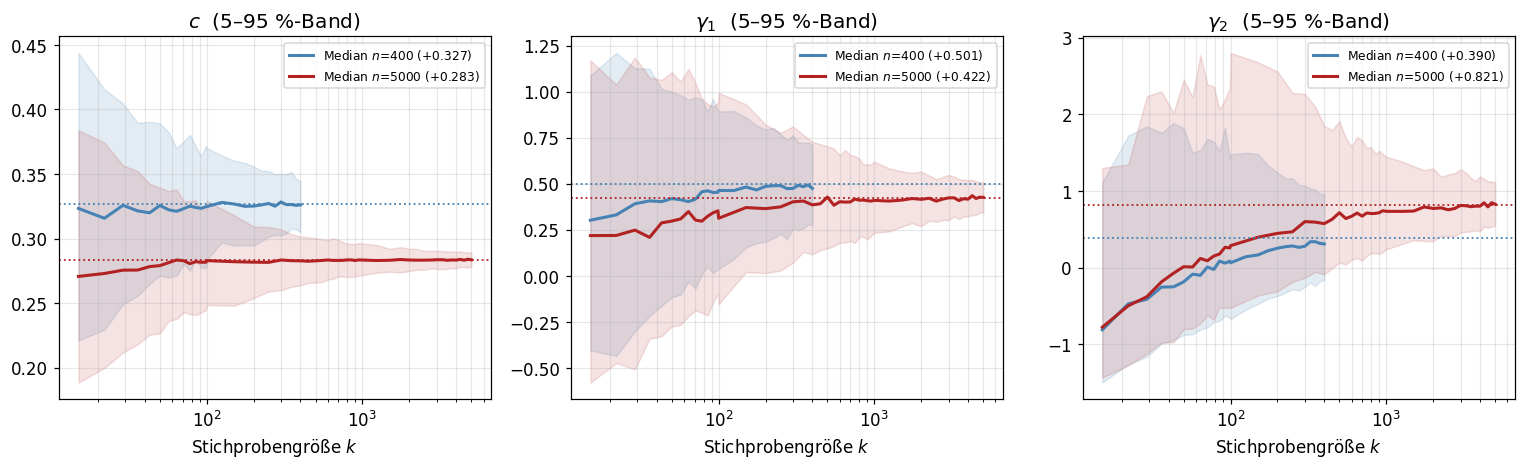

Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):
  n=400,  k=400 :  c=0.0127 (Formel 0.0126) | g1=0.1355 (sqrt(6/k) 0.1225) | g2=0.3687 (sqrt(24/k) 0.2449)
  n=5000, k=400 :  c=0.0121 (Formel 0.0119) | g1=0.1820 (sqrt(6/k) 0.1225) | g2=0.6087 (sqrt(24/k) 0.2449)
  n=5000, k=5000:  c=0.0034 (Formel 0.0034) | g1=0.0508 (sqrt(6/k) 0.0346) | g2=0.1738 (sqrt(24/k) 0.0693)   <- volle erreichbare Praezision

(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def moments(d):
    s = d.std(ddof=1); u = d - d.mean()
    return beta*s, float((u**3).mean()/s**3), float((u**4).mean()/s**4-3)

def boot_band(dE, ks, nboot=400, seed=0):
    rng = np.random.default_rng(seed); n = dE.size
    out = {q: {j: [] for j in range(3)} for q in ("med","lo","hi")}
    for k in ks:
        M = np.empty((nboot, 3))
        for b in range(nboot):
            M[b] = moments(dE[rng.integers(0, n, k)])
        for j in range(3):
            out["med"][j].append(np.median(M[:, j]))
            out["lo"][j].append(np.percentile(M[:, j], 5))
            out["hi"][j].append(np.percentile(M[:, j], 95))
    return {q: {j: np.array(v) for j, v in out[q].items()} for q in out}

dE4 = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))          # 400 Frames
dEf = np.subtract(*load_full("mace-L2-c-01"))                             # 5000, bereinigt
t4  = moments(dE4); tf = moments(dEf)
c0, g10, g20 = t4          # 400er-Referenz (ensemble_L2c) fuer 6.3

ks4 = np.unique(np.r_[np.arange(15,100,7), np.arange(100,401,25)])
ksf = np.unique(np.r_[np.arange(15,100,7), np.arange(100,1000,50), np.arange(1000,5001,250)])
b4  = boot_band(dE4, ks4); bf = boot_band(dEf, ksf)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.4))
labs = ["$c$", "$\\gamma_1$", "$\\gamma_2$"]
for j, (ax, lab) in enumerate(zip(axs, labs)):
    ax.semilogx(ks4, b4["med"][j], color="steelblue", lw=2, label=f"Median $n$=400 ({t4[j]:+.3f})")
    ax.fill_between(ks4, b4["lo"][j], b4["hi"][j], color="steelblue", alpha=0.15)
    ax.semilogx(ksf, bf["med"][j], color="firebrick", lw=2, label=f"Median $n$=5000 ({tf[j]:+.3f})")
    ax.fill_between(ksf, bf["lo"][j], bf["hi"][j], color="firebrick", alpha=0.13)
    ax.axhline(t4[j], color="steelblue", ls=":", lw=1.2)
    ax.axhline(tf[j], color="firebrick", ls=":", lw=1.2)
    ax.set_xlabel("Stichprobengröße $k$"); ax.set_title(f"{lab}  (5–95 %-Band)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

# Bootstrap-SE vs. Normaltheorie-Formel
def se_line(dE, k, seed=1):
    rng = np.random.default_rng(seed)
    B = np.array([moments(dE[rng.integers(0, dE.size, k)]) for _ in range(1000)])
    se = B.std(axis=0); c0, g10, g20 = moments(dE)
    return (f"  c={se[0]:.4f} (Formel {c0*np.sqrt((g20+2)/(4*k)):.4f}) | "
            f"g1={se[1]:.4f} (sqrt(6/k) {np.sqrt(6/k):.4f}) | "
            f"g2={se[2]:.4f} (sqrt(24/k) {np.sqrt(24/k):.4f})")
print("Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):")
print(f"  n=400,  k=400 :{se_line(dE4, 400)}")
print(f"  n=5000, k=400 :{se_line(dEf, 400)}")
print(f"  n=5000, k=5000:{se_line(dEf, 5000)}   <- volle erreichbare Praezision")
print("\n(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)")

**Drei Beobachtungen:**

- **Konvergenzgeschwindigkeit.** $c$ ist schon bei kleinem $k$ **unverzerrt** (der Median trifft den wahren Wert), seine **Präzision** verbessert sich aber weiter. Die SE-Formel aus §6.1 ist $\mathrm{SE}(c)/c=\sqrt{(\gamma_2+2)/4k}$; nach $k$ aufgelöst (mit $\varepsilon\equiv\mathrm{SE}(c)/c$) wird daraus $k=(\gamma_2+2)/(4\varepsilon^2)$. Damit entspricht $\varepsilon=20\,\%$ gerade $k\approx15$, $\varepsilon=10\,\%$ etwa $k\approx60$, $\varepsilon=5\,\%$ erst $k\approx240$. $\gamma_1$ und $\gamma_2$ folgen derselben $\sqrt{1/k}$-Rate mit größeren Vorfaktoren; die üblichen Werte $\sqrt{6/k}$ und $\sqrt{24/k}$ gelten allerdings **nur unter Normalität** und unterschätzen hier (siehe unten).
- **Was der große Satz bringt.** Die roten Bänder laufen bis $k=5000$ und schrumpfen weit unter das, was 400 Frames erlauben — bei $k=5000$ ist $c$ auf rund $\pm2\,\%$ bestimmt, $\gamma_2$ auf etwa $\pm0.2$. Die $k$-Schwellen selbst (15/60/240 für 20/10/5 %) sind aber **skalenfrei**: sie hängen nur an $\gamma_2$, nicht am Pool. Der große Satz senkt also nicht die Schwelle, sondern erlaubt, sie zu **überschreiten**.
- **Bias bei kleinem $k$.** $\gamma_1,\gamma_2$ sind nach unten verzerrt (bei $k=15$ deutlich unter dem Endwert): unterschätzte Schiefe → schwächere Formkorrektur → Schranke näher an Gauß. Unter einer **zweiseitigen** Regel wäre das die sichere Richtung (konservativer, nie fälschlich PASS). Unter der **einseitigen** Regel aus §7.1 ist „konservativer" aber genau die einzige verbleibende Fehlerart — der Bias zeigt dort ins Unsichere. §8.3 beziffert den Preis und zieht daraus die Konsequenz, erst ab $k=n/10$ zu schauen.

Der Bootstrap-SE für $\gamma_2$ liegt in **beiden** Pools über der Normaltheorie-Formel — die Warnung aus 6.1 bestätigt sich unabhängig von $n$.

### 6.3 Fehlerfortpflanzung — warum die langsame Konvergenz unkritisch ist

$\gamma_1,\gamma_2$ gehen nicht direkt in $N_\text{eff}$ ein, sondern gedämpft über $c^3$ bzw.
$c^4$. Ihre Unsicherheit pflanzt sich also als $\mathrm{SE}(\gamma_1)\,c^3$ und
$\mathrm{SE}(\gamma_2)\,c^4$ fort — bei kleinem $c$ winzig.

SE bei k=400, per Bootstrap: SE(g1)=0.1379 (Normaltheorie 0.1225), SE(g2)=0.3642 (0.2449)
Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit:

     c      -c^2            +g1 c^3    -7/12 g2 c^4
  0.33    0.1069    0.0175 ± 0.0048        0.0026   (  0.5 % auf N_eff)
  0.50    0.2500    0.0626 ± 0.0172        0.0142   (  1.7 % auf N_eff)
  0.70    0.4900    0.1718 ± 0.0473        0.0546   (  4.8 % auf N_eff)
  1.00    1.0000    0.5008 ± 0.1379        0.2275   ( 14.8 % auf N_eff)


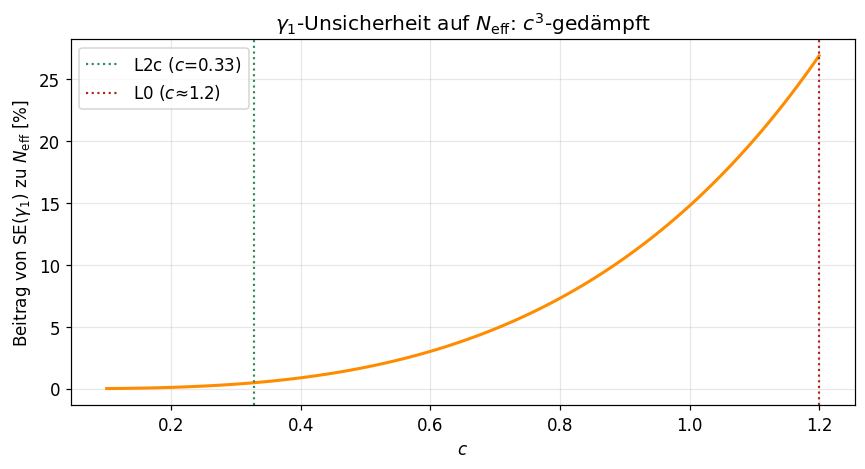

In [17]:
# §6.1 verwirft die Normaltheorie-Formeln fuer gamma1, gamma2 ausdruecklich, und
# §6.2 zeigt sie numerisch als zu klein. Also hier ebenfalls Bootstrap statt
# sqrt(6/k) bzw. sqrt(24/k) -- sonst widerspraeche die Zelle der davor.
_rngS = np.random.default_rng(7)
_B = np.array([moments(dE4[_rngS.integers(0, dE4.size, 400)]) for _ in range(1200)])
SEg1, SEg2 = _B[:, 1].std(ddof=1), _B[:, 2].std(ddof=1)
print(f"SE bei k=400, per Bootstrap: SE(g1)={SEg1:.4f} (Normaltheorie "
      f"{np.sqrt(6/400):.4f}), SE(g2)={SEg2:.4f} ({np.sqrt(24/400):.4f})")
print("Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit:\n")
print(f"{'c':>6}{'-c^2':>10}{'+g1 c^3':>19}{'-7/12 g2 c^4':>16}")
for c in (0.327, 0.5, 0.7, 1.0):
    t2 = c**2; t3 = g10*c**3; t4 = 7/12*g20*c**4
    se3 = c**3*SEg1                  # dominanter Beitrag der g1-Unsicherheit
    rel = 100*(np.exp(se3) - 1)      # exakt: se3 wirkt im Exponenten, nicht additiv
    print(f"{c:>6.2f}{t2:>10.4f}{t3:>10.4f} ± {se3:<6.4f}{t4:>14.4f}"
          f"   ({rel:>5.1f} % auf N_eff)")

# g1-Unsicherheit auf N_eff als Funktion von c
cc = np.linspace(0.1, 1.2, 100)
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(cc, 100*(np.exp(cc**3*SEg1) - 1), color="darkorange", lw=2)
ax.axvline(0.327, color="seagreen", ls=":", lw=1.4, label="L2c ($c$=0.33)")
ax.axvline(1.2, color="firebrick", ls=":", lw=1.4, label="L0 ($c$≈1.2)")
ax.set_xlabel("$c$"); ax.set_ylabel("Beitrag von SE($\\gamma_1$) zu $N_\\mathrm{eff}$ [%]")
ax.set_title("$\\gamma_1$-Unsicherheit auf $N_\\mathrm{eff}$: $c^3$-gedämpft")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Die Auflösung.** Bei L2c ($c=0.33$) trägt die $\gamma_1$-Unsicherheit nur **0,5 %** zu
$N_\text{eff}$ bei — obwohl $\gamma_1$ selbst auf ~28 % genau ist. Der $c^3$-Faktor (0.036)
dämpft alles weg. Erst bei $c\gtrsim0{,}7$ wird der Beitrag spürbar (4,8 %), und bei
$c\approx1$ (L0) sind es 14,8 % — aber dort divergiert die Reihe ohnehin (§2.5, §4.4), und man nimmt den
exakten Kish-Wert.

$\gamma_1,\gamma_2$ sind also **essenziell für den Wert** (§5); ihre langsame und verzerrte
Konvergenz ist bei kleinem $c$ zusätzlich $c^3$-gedämpft. Die **Richtung** des Bias ist
dagegen nicht harmlos — unter der einseitigen Regel zeigt sie ins Unsichere (§6.2), und
genau deshalb setzt der Workflow den ersten Blick erst bei $k=n/10$ an.

### 6.4 Konsequenz

- **$c$** ist die tragende Größe: unverzerrt ab $k\approx15$ (dort $\pm20\,\%$), auf $\pm10\,\%$
  ab $k\approx60$, mit SE $\sqrt{(\gamma_2+2)/4k}$ — und die einzige, die in die Schranke
  $c\le c_\text{max}$ eingeht. Liegt $c$ weit von $c_\text{max}$ (L0: $1{,}2$ gegen $\approx0{,}50$),
  ist das Urteil unstrittig; nahe der Schwelle braucht es mehr Punkte. Der Workflow schaut
  deshalb erst ab $k=n/10$ (§7.1) — dort ist $c$ auf rund $\pm11\,\%$ bestimmt.
- **$\gamma_1,\gamma_2$** rechnet man mit, weil ohne sie keine Schranke bestimmbar ist (§5).
  Ihre Ungenauigkeit gefährdet die Prognose kaum (bei kleinem $c$ gedämpft), verschiebt aber
  die **Schranke** — und zwar bei kleinem $k$ systematisch nach unten, also in die Richtung,
  die unter der einseitigen Regel den Fehler erzeugt (§6.2).

Damit steht das Fundament für §7: die Entscheidung ruht auf dem schnell konvergierenden $c$,
die Formkorrekturen verschieben die Schranke. Wie weit man dieser Verschiebung bei kleinem
$k$ trauen darf, misst §8.3.

<a id="7"></a>
## 7. Der sequenzielle Workflow

*Die Abbruchregel, ihre Werkzeuge, und ob sie auf den echten Modellen trifft.*

Kapitel 8 klärt anschließend, **unter welchen Bedingungen** sie trägt — wie oft geschaut
wird, welche Schranke sie braucht und wie unsicher diese selbst ist.

### 7.1 Die Entscheidungsregel

Der Workflow sammelt DFT-Punkte **iterativ** und prüft laufend, ob das Reweighting noch
tragen kann. Die Regel ist **einseitig** und vergleicht zwei Bänder: das untere Ende der
Schätzung $\hat c$ gegen das obere Ende der Schranke $\hat c_\text{max}$.

$$\hat c(k) - \mathrm{SE}\big(\hat c(k)\big)
\;>\;
\hat c_\text{max}(k) + \mathrm{SE}\big(\hat c_\text{max}(k)\big)
\;\Longrightarrow\; \text{FAIL, abbrechen}, \qquad
\text{sonst} \;\Longrightarrow\; \text{weiterrechnen.}$$

**Beide Seiten sind laufende Schätzungen.** $\hat c(k)$ kommt aus $\mathrm{std}(\Delta E)$,
$\hat c_\text{max}(k)$ aus $\hat\gamma_1(k),\hat\gamma_2(k)$ über die Quartik (2.9) — die
Schranke verschiebt sich mit jedem neuen Punkt genauso wie die Größe, die gegen sie geprüft
wird. Beide Bänder schrumpfen wie $1/\sqrt k$; FAIL wird erst behauptet, wenn sie sich
trennen.

**Ein Standardfehler je Seite.** Ein Vorfaktor $q$ steht bewusst nicht in der Formel. Bei
zwei verglichenen Bändern wäre er kein Niveau: nichtüberlappende Konfidenzbänder sind ein
konservativer Test für eine Differenz, ein nominelles 5-%-$q$ wäre effektiv etwa 0,5 %. Statt
eine Niveauaussage zu treffen, die nicht hält, ist die Bandbreite eine Konvention. Was sie
kostet, misst §8.3 — die Umgebung ist kein Plateau, ein halber Standardfehler mehr oder
weniger verschiebt die Erkennung bei $\rho=1{,}1$ um rund 20 Prozentpunkte.

**PASS wird nie behauptet.** Ein frühes PASS spart nichts — die Gewichte $w_i$ braucht man
am Ende ohnehin vollständig. Nur ein frühes FAIL spart Rechenzeit. Damit bleibt genau
**eine** Fehlerart: ein Modell abbrechen, das die Bedingung erfüllt hätte.

| Bestandteil | was | begründet in |
|---|---|---|
| Schranke $c_\text{max}^\text{schief}$ | Quartik (2.9) mit $\hat\gamma_1(k),\hat\gamma_2(k)$ | §8.2 |
| $\mathrm{SE}(\hat c)$ | analytisch, $\hat c\sqrt{(\hat\gamma_2+2)/4k}$ | §6.1, §8.3 |
| $\mathrm{SE}(\hat c_\text{max})$ | gebootstrappt, auf denselben Resamples | §8.3 |
| Bandbreite | ein Standardfehler je Seite | §8.3 |
| Checkpoints | geometrisches Raster statt jedes $k$ | §8.1 |
| **erster Blick bei $n/10$** | 8 Blicke, skalenfrei | §7.2, §8.3 |

Dass die eine Unsicherheit analytisch kommt und die andere gebootstrappt, ist kein
Stilbruch, sondern gemessen (§8.3): die Formel aus §6.1 trifft den Bootstrap derselben
Sequenz auf 3 %, die analoge Delta-Methode für $c_\text{max}$ dagegen nicht — dort steht
$f'(c_\text{max})$ im Nenner und geht bei verrauschtem $\hat\gamma_1$ gegen null.

**Faustregel für den ersten Blick: 10 % der ohnehin geplanten Punkte** — bei $n=500$ also
ab $k=50$, bei $n=5000$ ab $k=500$; das geometrische Raster liefert in beiden Fällen acht
Blicke. Früher zu schauen bringt fast nichts: die Ersparnis liegt dann ohnehin schon bei
90 %, während unterhalb davon nicht nur $\mathrm{SE}(c)$ groß ist, sondern auch die
**Schranke selbst** unzuverlässig geschätzt wird (§8.3). Die Messung in §8.3 zeigt: der
spätere Start senkt die Fehlalarmrate um rund eine Größenordnung und **verbessert** dabei
sogar die Erkennung — die frühen Blicke haben fast nur Fehlalarme beigetragen.

In [18]:
# Werkzeuge fuer den Workflow liegen in src/uq_mace/screening.py -- ausgelagert,
# damit sie testbar sind und die Analyse-Skripte sie importieren statt zu
# duplizieren. Alles darin ist KAUSAL: jede Groesse bei Punkt k benutzt
# ausschliesslich dE[:k], auch gamma1, gamma2 und die daraus gebildete Schranke.
from uq_mace import screening as scr
from uq_mace.screening import (
    C_VALID, CHECKPOINTS, K_FLOOR, R5_TOL, checkpoint_grid, cmax_skew,
    cmax_skew_vec, log_neff_ratio, monitor_split, run_stats, run_stats_2d,
    se_c, stat_D,
)

_ctx = scr.configure(beta=beta, R=0.8)
R, LNR, cmax = _ctx["R"], _ctx["LNR"], _ctx["cmax_gauss"]

# --- Verifikationen: die Naeherungen gegen ihre exakten Gegenstuecke ----------
# cmax_skew loest die Quartik exakt (numpy.roots ueber die Begleitmatrix),
# cmax_skew_vec naehert sie mit Newton -- schnell genug fuer den Hot Path von
# monitor_split. Der Vergleich hier ist der Kurzcheck; tests/test_screening.py
# faehrt ihn ueber ein Gitter aus rund 4000 Parameterpaaren, inklusive der
# Faelle mit zwei Wurzeln unterhalb C_VALID.
_g1t = np.array([0.501, 0.413, 0.207, 0.247, 0.0, -0.5, 0.9])
_g2t = np.array([0.390, 0.186, 0.140, 0.094, 0.0,  0.4, 1.5])
_ref = np.array([cmax_skew(R, a, b, warn=False) for a, b in zip(_g1t, _g2t)])
print(f"cmax_skew_vec (Newton) vs. cmax_skew (exakt): max. Abweichung "
      f"{np.abs(_ref - cmax_skew_vec(_g1t, _g2t)).max():.1e}   (7 Testpaare)")

_d = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))[:200]
_k1, _c1, _a1, _b1 = run_stats(_d)
_k2, _c2, _a2, _b2 = run_stats_2d(_d[None, :])
_m = _k1 >= K_FLOOR
print(f"run_stats_2d vs. run_stats                  : c "
      f"{np.nanmax(np.abs(_c1-_c2[0])[_m]):.1e}, "
      f"g1 {np.nanmax(np.abs(_a1-_a2[0])[_m]):.1e}, "
      f"g2 {np.nanmax(np.abs(_b1-_b2[0])[_m]):.1e}   (k >= {K_FLOOR})")

# --- Die Regel und ihre Bestandteile -----------------------------------------
# monitor_split ist die verwendete Regel: je ein Band um c und um c_max, kein
# Vorfaktor. Die frueheren Fassungen -- monitor_boot (ein Bootstrap-Band um
# D = c - c_max mit q = 1.64), decide_naive und fail_only_2d -- stehen weiterhin
# in uq_mace.screening und in tests/test_screening.py, werden hier aber nicht
# mehr gebraucht und deshalb auch nicht importiert.
print(f"\nRegel: c(k) - SE(c) > c_max(k) + SE(c_max)   ->   FAIL")
print(f"  SE(c)     analytisch, c*sqrt((gamma2+2)/4k)   (§6.1)")
print(f"  SE(c_max) gebootstrappt, dieselben Resamples  (§8.3)")
print(f"  Band      = 1 SE je Seite, kein Vorfaktor    (§8.3)")

print(f"\nR = {R};  c_max(Gauss) = {cmax:.4f}")
print(f"Gueltigkeitsgrenze der Reihe: c <= C_VALID = {C_VALID:.4f}  "
      f"(Restglied (2c)^5/5! <= {R5_TOL})")
print(f"Checkpoints fuer n=500 : {list(checkpoint_grid(500))}")
print(f"Checkpoints fuer n=5000: {list(checkpoint_grid(5000))}")
print("c_max^schief haengt von gamma1, gamma2 ab und wird je Lauf neu bestimmt.")

cmax_skew_vec (Newton) vs. cmax_skew (exakt): max. Abweichung 5.6e-16   (7 Testpaare)
run_stats_2d vs. run_stats                  : c 0.0e+00, g1 0.0e+00, g2 0.0e+00   (k >= 50)

Regel: c(k) - SE(c) > c_max(k) + SE(c_max)   ->   FAIL
  SE(c)     analytisch, c*sqrt((gamma2+2)/4k)   (§6.1)
  SE(c_max) gebootstrappt, dieselben Resamples  (§8.3)
  Band      = 1 SE je Seite, kein Vorfaktor    (§8.3)

R = 0.8;  c_max(Gauss) = 0.4724
Gueltigkeitsgrenze der Reihe: c <= C_VALID = 0.7155  (Restglied (2c)^5/5! <= 0.05)
Checkpoints fuer n=500 : [np.int64(50), np.int64(70), np.int64(98), np.int64(137), np.int64(192), np.int64(269), np.int64(377), np.int64(500)]
Checkpoints fuer n=5000: [np.int64(500), np.int64(700), np.int64(980), np.int64(1372), np.int64(1921), np.int64(2689), np.int64(3765), np.int64(5000)]
c_max^schief haengt von gamma1, gamma2 ab und wird je Lauf neu bestimmt.


### 7.2 Der Workflow auf den echten Modellen

Jetzt der Test, auf den es ankommt: die Regel aus §7.1 mit Checkpoints und gebootstrapptem
Band, angewendet auf die drei Modelle des $n=5000$-Satzes. Je Modell zehn Wiederholungen zu
500 Punkten.

**Wichtig für die Bewertung:** in jeder Wiederholung werden **alle** 500 Punkte gerechnet,
auch wenn der Monitor längst abgebrochen hätte. Nur so lässt sich sein Urteil gegen das
exakte $N_\text{eff}/500$ **derselben** Daten prüfen — schrankenfrei, ohne Reihenentwicklung
(§2.1). Im Produktivbetrieb würde man an der Stelle natürlich aufhören; hier wird
weitergerechnet, um zu messen, ob das Aufhören richtig gewesen wäre.

Die Tabelle führt je Wiederholung $c(500)$, die daraus bestimmte Schranke $c_\text{max}(500)$
und ihr Verhältnis mit, damit sichtbar ist, wie weit der jeweilige Lauf von der
Entscheidungsgrenze entfernt liegt.

In [19]:
# ===========================================================================
# Der Workflow, wie er laufen wuerde: Checkpoints + zwei Baender.
# Fuer JEDE Wiederholung werden trotzdem ALLE k_target Punkte gerechnet, damit
# das Monitor-Urteil gegen das exakte N_eff derselben Daten geprueft werden kann.
# ===========================================================================
N_REPS, K_TARGET = 10, 500

def kish_ratio_rows(dE):
    """Exaktes N_eff/n je Zeile -- auf ALLEN Punkten, schrankenfrei (§2.1)."""
    w = np.exp(-beta*(dE - dE.min(axis=1, keepdims=True)))   # Offset egal (§2.2)
    return (w.sum(1)**2 / np.sum(w**2, 1)) / dE.shape[1]

def khat_rows(dE):
    """Tail-Index je Zeile -- das Gate aus A2 (§3.2). Nur fuer khat < 0.5 existiert
    E[w^2], und nur dann bedeutet c <= c_max ueberhaupt N_eff/n >= R."""
    w = np.exp(-beta*(dE - dE.min(axis=1, keepdims=True)))
    return np.array([psis_khat(row) for row in w])

print(f"R = {R}   ->   c_max(Gauss) = {cmax:.4f};  c_max^schief wird je Lauf aus "
      f"gamma1(k), gamma2(k) neu bestimmt")
print(f"Checkpoints: {list(CHECKPOINTS)}   |   Band = 1 SE je Seite   |   {N_REPS} "
      f"Wiederholungen a {K_TARGET} Punkte je Modell\n")

rng_seq  = np.random.default_rng(42)    # zieht die Sequenzen
rng_boot = np.random.default_rng(43)    # Bootstrap im Monitor -- getrennter Strom,
                                        # sonst haengen die Sequenzen des zweiten
                                        # Modells davon ab, wie viele Zufallszahlen
                                        # der Bootstrap des ersten verbraucht hat.
summary = []
for model in MODELS_FULL:
    e_dft_pool, e_mace_pool = load_full(model)
    idx = rng_seq.integers(0, e_dft_pool.size, size=(N_REPS, K_TARGET))
    dE = (e_dft_pool - e_mace_pool)[idx]

    # monitor_split: FAIL sobald c(k) - SE(c) > c_max(k) + SE(c_max). SE(c) kommt
    # analytisch aus §6.1, SE(c_max) aus B Resamples je Checkpoint -- bei nur
    # N_REPS Sequenzen ist B hoch gewaehlt, sonst streut die Schwelle selbst.
    fired, kfire = monitor_split(dE, rng=rng_boot, B=300)
    _, c_run, g1_run, g2_run = stat_D(dE)            # Kennzahlen auf allen 500
    cmax_run = cmax_skew_vec(g1_run, g2_run)
    neff = kish_ratio_rows(dE)                       # die Wahrheit, alle 500 Punkte
    khat = khat_rows(dE)                             # Gate aus A2 (§3.2)
    truth_fail = neff < R

    print(f"=== {model}   (Pool n={e_dft_pool.size}, bereinigt) ===")
    print(f"{'rep':>4}{'c(500)':>9}{'c_max(500)':>12}{'rho':>7}{'N_eff/500':>11}"
          f"{'khat':>8}{'wahr':>7}{'FAIL bei k':>12}   {'Urteil':<19}")
    print("-"*88)
    n_ok = n_alarm = n_miss = 0
    for r in range(N_REPS):
        if fired[r]:
            kstr = str(kfire[r])
            if truth_fail[r]: verdict, n_ok = "korrekt", n_ok+1
            else:             verdict, n_alarm = "FEHLALARM", n_alarm+1
            if khat[r] >= 0.5: verdict += " (Gate!)"
        else:
            kstr = "nie"
            if truth_fail[r]: verdict, n_miss = "verpasst", n_miss+1
            else:             verdict, n_ok = "korrekt (weiter)", n_ok+1
        print(f"{r+1:>4}{c_run[r]:>9.3f}{cmax_run[r]:>12.3f}"
              f"{c_run[r]/cmax_run[r]:>7.2f}{neff[r]:>11.3f}{khat[r]:>8.2f}"
              f"{('FAIL' if truth_fail[r] else 'PASS'):>7}{kstr:>12}   {verdict:<19}")
    ks = kfire[fired]
    saved = 100*(1 - ks.mean()/K_TARGET) if ks.size else 0.0
    print(f"  -> korrekt {n_ok}/{N_REPS}, Fehlalarme {n_alarm}, verpasst {n_miss}"
          + (f", Median k bei FAIL = {np.median(ks):.0f}, DFT gespart {saved:.0f} %"
             if ks.size else ", nie gefeuert (richtig, da PASS)"))
    print()
    summary.append((model, n_ok, n_alarm, n_miss))

print("Zusammenfassung")
print(f"{'Modell':<15}{'korrekt':>9}{'Fehlalarm':>11}{'verpasst':>10}")
for m, a, b, c_ in summary:
    print(f"{m:<15}{a:>7}/{N_REPS}{b:>11}{c_:>10}")
print("\n'Fehlalarm' = FAIL gefeuert, obwohl N_eff/500 >= R  -- der einzige echte Fehler.")
print("'verpasst'  = nie gefeuert, obwohl N_eff/500 < R  -- kein Fehler, nur keine Ersparnis:")
print("              man rechnet den Lauf zu Ende und sieht es am exakten Kish-Wert.")
print("'(Gate!)'   = khat >= 0.5: E[w^2] existiert nicht, N_eff hat keinen Populations-")
print("              grenzwert -- das Urteil ist dort nicht belastbar (§3.2).")

R = 0.8   ->   c_max(Gauss) = 0.4724;  c_max^schief wird je Lauf aus gamma1(k), gamma2(k) neu bestimmt
Checkpoints: [np.int64(50), np.int64(70), np.int64(98), np.int64(137), np.int64(192), np.int64(269), np.int64(377), np.int64(500)]   |   Band = 1 SE je Seite   |   10 Wiederholungen a 500 Punkte je Modell

=== mace-L0-01   (Pool n=4996, bereinigt) ===
 rep   c(500)  c_max(500)    rho  N_eff/500    khat   wahr  FAIL bei k   Urteil             
----------------------------------------------------------------------------------------
   1    1.328       0.476   2.79      0.235    0.53   FAIL          50   korrekt (Gate!)    
   2    1.310       0.500   2.62      0.313    0.13   FAIL          50   korrekt            
   3    1.328       0.499   2.66      0.236    0.50   FAIL          50   korrekt (Gate!)    
   4    1.303       0.486   2.68      0.220    0.57   FAIL          50   korrekt (Gate!)    
   5    1.343       0.480   2.80      0.220    0.47   FAIL          50   korrekt           

**Lesart.** Alle drei Modelle werden in allen zehn Wiederholungen **korrekt** eingestuft:
die beiden L0-Varianten brechen ab (exaktes $N_\text{eff}/500 = 0{,}15$–$0{,}40$, weit unter
$R=0{,}8$), mace-L2-c-01 läuft durch ($\approx0{,}93$). Null Fehlalarme, null verpasste
FAILs. Der Abbruch fällt durchweg beim **ersten** Checkpoint, also bei $n/10$ — **90 %**
gesparte DFT-Punkte, und zwar unabhängig von $n$: bei einem Produktionslauf mit $n=5000$
läge der erste Blick bei $k=500$ und die Ersparnis wieder bei 90 %.

Für das PASS-Modell ist die Ersparnis null. Das ist kein Mangel, sondern die Konsequenz
daraus, dass die Regel nie PASS behauptet.

**Zur $\hat k$-Spalte.** Bei mace-L0-01 überschreitet $\hat k$ in einzelnen Läufen $0{,}5$,
was nach A2 (§3.2) das Gate verletzen würde. Das ist **Schätzerrauschen, nicht das Gate**:
auf dem vollen Pool ($n\approx5000$) liegt $\hat k$ bei 0,31 / 0,22 / 0,02, während
$\mathrm{SE}(\hat k)\approx0{,}15$ bei $n=500$ beträgt — rund ein Fünftel der Ziehungen
landet damit zufällig über der Schwelle, und zwar auch beim Ziehen ohne Zurücklegen. **Das
Gate ist auf dem vollen Testsatz zu prüfen, nicht je Sequenz.** Für das FAIL-Urteil ist das
ohnehin unerheblich, weil es an $c$ gegen $c_\text{max}$ hängt und nicht am
$N_\text{eff}$-Wert.

Die Spalte $\rho=c/c_\text{max}$ zeigt schließlich, warum dieser Test leicht ist: die
L0-Läufe liegen beim 2,6- bis 2,8-fachen ihrer Schranke, der L2-Lauf bei knapp der Hälfte.
Kein Lauf kommt der Entscheidungsgrenze nahe — was dort passiert, klärt Kapitel 8.

### 7.3 Ist die Regel geprüft?

§7.2 zeigt, dass die Regel auf den echten Modellen richtig entscheidet. Für sich genommen
ist das ein schwaches Argument: eine Regel, die *nie* feuert, läge auf `mace-L2-c-01`
ebenso richtig, und eine, die *immer* feuert, auf beiden L0-Modellen. Die Frage ist deshalb
nicht, ob die Prüfung durchläuft, sondern ob sie einen **Fehler bemerken würde**.

Das lässt sich messen. Die Entscheidungszeile

$$\hat c(k) - \mathrm{SE}(\hat c) \;>\; \hat c_\text{max}(k) + \mathrm{SE}(\hat c_\text{max})$$

wird gezielt beschädigt — einmal ohne $\mathrm{SE}(\hat c_\text{max})$, einmal ohne
$\mathrm{SE}(\hat c)$, einmal ganz ohne Band — und für jede Variante wird geprüft, ob sich
das Urteil ändert. Eine Prüfung, die alle Varianten passieren lässt, prüft nichts.

Die Bibliothek wird dabei nicht verändert; die Varianten sind lokale Bandfunktionen.
Verglichen wird auf zwei Datensätzen: den echten Modellen wie in §7.2, und **derselben**
$\Delta E$-Verteilung auf $\rho=1{,}15$ skaliert — also mit der gemessenen Form
($\gamma_1=0{,}50$, $\gamma_2=0{,}39$), nur dicht an der Schranke.

In [20]:
# --- Mutationsprobe: wuerde eine kaputte Regel auffallen? --------------------
# Statt zu fragen "laeuft die Pruefung durch", wird die Entscheidungszeile gezielt
# beschaedigt und gemessen, ob sich das Urteil aendert. uq_mace.screening wird
# dabei NICHT veraendert -- die Varianten sind lokale Bandfunktionen.
BAENDER = {
    "echte Regel":         lambda sc, scm: sc + scm,
    "SE(c_max) fehlt":     lambda sc, scm: sc,
    "SE(c) fehlt":         lambda sc, scm: scm,
    "Baender subtrahiert": lambda sc, scm: sc - scm,
    "gar kein Band":       lambda sc, scm: np.zeros_like(sc),
    "2*SE(c) statt Summe": lambda sc, scm: 2 * sc,
}

def feuert(sub, band_fn, B=200, seed=5):
    """Feuert die Regel bei k = sub.shape[1]?  Ein Checkpoint, eine Bandvariante."""
    k = sub.shape[1]
    D, c, g1, g2 = stat_D(sub)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, k, (sub.shape[0], B, k))
    boot = np.take_along_axis(sub[:, None, :], idx, axis=2).reshape(-1, k)
    Db, cb, _, _ = stat_D(boot)
    se_cmax = (cb - Db).reshape(sub.shape[0], B).std(1)
    return D > band_fn(se_c(c, g2, k), se_cmax)

# (a) Grenzfall: reale dE-Form, auf rho = 1.15 skaliert. Nur hier entscheidet die
#     Bandbreite ueberhaupt etwas.
_dl = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))
_sl = _dl.std(ddof=1); _ul = _dl - _dl.mean()
_g1l = float((_ul**3).mean()/_sl**3); _g2l = float((_ul**4).mean()/_sl**4 - 3.0)
_csl = cmax_skew(R, _g1l, _g2l, warn=False)
_pool = _dl.mean() + (1.15*_csl/(beta*_sl)) * (_dl - _dl.mean())
GRENZ = _pool[np.random.default_rng(11).integers(0, _pool.size, (300, 100))]

# (b) Echte Modelle, genau der Aufbau aus §7.2, beim ersten Checkpoint
_rs73 = np.random.default_rng(42)
ECHT = {m: (lambda a, b: (a - b)[_rs73.integers(0, a.size, (10, 500))][:, :50])(*load_full(m))
        for m in MODELS_FULL}

_ref = feuert(GRENZ, BAENDER["echte Regel"])
print("Wuerde eine kaputte Regel auffallen?\n")
print(f"{'Bandvariante':<22} | {'Grenzfall: feuert':>18}{'Urteil anders':>15} | "
      f"{'echte Modelle':>15}{'Urteil anders':>15}")
print("-" * 92)
for _name, _fn in BAENDER.items():
    _g = feuert(GRENZ, _fn)
    _abw = np.mean(_g != _ref)
    _ok = all(feuert(ECHT[m], _fn).mean() == (0.0 if m == "mace-L2-c-01" else 1.0)
              for m in MODELS_FULL)
    _s1 = "REFERENZ" if _name == "echte Regel" else f"{_abw:.0%}"
    _s2 = "REFERENZ" if _name == "echte Regel" else ("nein" if _ok else "ja")
    print(f"{_name:<22} | {_g.mean():>17.1%}{_s1:>15} | "
          f"{('10/10 richtig' if _ok else 'falsch'):>15}{_s2:>15}")

# (c) Wie weit sind die echten Modelle von der Entscheidungslinie?
print("\n\nAbstand zur Entscheidungslinie bei k=50, in Bandbreiten:")
print(f"{'Modell':<15}{'D':>9}{'SE(c)+SE(c_max)':>18}{'D / Band':>11}")
print("-" * 54)
for _m in MODELS_FULL:
    _sub = ECHT[_m]
    _D, _c, _, _g2 = stat_D(_sub)
    _idx = np.random.default_rng(43).integers(0, 50, (_sub.shape[0], 200, 50))
    _bo = np.take_along_axis(_sub[:, None, :], _idx, axis=2).reshape(-1, 50)
    _Db, _cb, _, _ = stat_D(_bo)
    _band = se_c(_c, _g2, 50) + (_cb - _Db).reshape(_sub.shape[0], 200).std(1)
    print(f"{_m:<15}{_D.mean():>9.3f}{_band.mean():>18.4f}{(_D/_band).mean():>11.1f}")

Wuerde eine kaputte Regel auffallen?

Bandvariante           |  Grenzfall: feuert  Urteil anders |   echte Modelle  Urteil anders
--------------------------------------------------------------------------------------------
echte Regel            |             40.7%       REFERENZ |   10/10 richtig       REFERENZ
SE(c_max) fehlt        |             71.7%            31% |   10/10 richtig           nein
SE(c) fehlt            |             72.0%            31% |   10/10 richtig           nein
Baender subtrahiert    |             89.7%            49% |   10/10 richtig           nein
gar kein Band          |             88.7%            48% |   10/10 richtig           nein
2*SE(c) statt Summe    |             34.7%             7% |   10/10 richtig           nein


Abstand zur Entscheidungslinie bei k=50, in Bandbreiten:
Modell                 D   SE(c)+SE(c_max)   D / Band
------------------------------------------------------
mace-L0-01         0.879            0.1748        5.1
mace-L0-c

**Der Echtdaten-Lauf aus §7.2 bemerkt keine dieser Beschädigungen.** Auch „gar kein Band"
liefert dort 10/10 richtig. Der Grund steht in der zweiten Tabelle: bei $k=50$ liegt $D$ um
Faktor 5,1 bzw. 3,6 über und 3,1 unter dem Band. Die Modelle sind drei bis fünf Bandbreiten
von der Entscheidungslinie entfernt, und dort ist jede Bandbreite zwischen null und dem
Dreifachen gleichwertig.

**Am Grenzfall greift die Prüfung dagegen.** Jede Beschädigung ändert dort zwischen 7 % und
49 % der Einzelurteile. Die beiden Datensätze unterscheiden sich nur in der Skala — die Form
der $\Delta E$-Verteilung ist in beiden die gemessene.

**Was §7.2 also leistet und was nicht.** Er zeigt, dass die Regel auf echten Daten läuft,
richtig entscheidet und 90 % der DFT-Punkte spart. Er kann nicht zeigen, dass die
Bandkonstruktion stimmt — dafür liegen die Modelle zu weit von der Schranke. Diesen Nachweis
führt Kapitel 8: dort wird dieselbe reale Verteilung schrittweise an die Schranke geschoben,
und dort trennt sich, welche Schranke (§8.2) und welches Band (§8.3) trägt.

Zwei weitere Einschränkungen, der Vollständigkeit halber:

- **Nur der erste Checkpoint wird ausgeübt.** Beide L0-Modelle feuern bei $k=50$; das
  geometrische Raster und das Verhalten bei wachsendem $k$ kommen in §7.2 nie zum Einsatz.
- **Die zehn Wiederholungen sind Ziehungen aus einem Pool**, keine zehn unabhängigen
  Experimente. „10/10" heißt: ein Datensatz, zehnmal betrachtet.

> **Dieselbe Probe auf der Bibliothek.** Die Zelle oben ist die im Notebook sichtbare
> Kurzfassung. In `tests/test_screening.py` laufen dieselben Beschädigungen gegen die
> dortigen Prüfungen; alle werden gefangen. Tragend sind
> `test_split_entscheidung_gegen_unabhaengige_nachrechnung` (Entscheidung Zeile für Zeile
> gegen eine getrennt hingeschriebene Rechnung), `test_split_bandbreite_wirkt`,
> `test_split_beide_unsicherheiten_gehen_ein` und
> `test_split_urteilt_richtig_bei_bekannter_wahrheit`.

<a id="8"></a>
## 8. Wo die Regel trägt

*Drei Entscheidungen stecken in der Regel aus §7.1, und alle drei sind messbar: wie oft
geschaut wird (§8.1), welche Schranke verglichen wird (§8.2), und warum die Schranke ein
eigenes Band braucht (§8.3). §8.4 zieht die Konsequenz.*

Gemessen wird durchgängig an `ensemble_L2c`, reskaliert auf einen vorgegebenen Abstand

$$\boxed{\;\rho \;=\; \frac{c}{c_\text{max}}\;}$$

und geprüft gegen eine **schrankenfreie** Wahrheit — das exakte Kish-$N_\text{eff}$ auf
einer sehr großen Stichprobe, ohne jede Kumulantennäherung. Es gilt
$\rho\le1 \iff N_\text{eff}/n\ge R \iff$ PASS. $\rho$ ist nicht auf $[0,1]$ beschränkt:
$c$ ist eine Eigenschaft des Modells, $c_\text{max}$ die vom Ziel $R$ erlaubte Obergrenze.

Die Reskalierung verschiebt nur die **Skala** der $\Delta E$-Verteilung; Schiefe und
Kurtosis bleiben die gemessenen ($\gamma_1=0{,}50$, $\gamma_2=0{,}39$). Alle Aussagen
unten beruhen damit auf der realen Form der Fehlerverteilung.

| Modell | $c$ | $c_\text{max}^\text{schief}$ | $\rho$ |
|---|---|---|---|
| ensemble_L2c | 0,327 | 0,529 | **0,62** |
| mace-L2-c-01 | 0,335 | 0,524 | **0,64** |
| mace-L0-c-01 | 1,079 | 0,493 | **2,19** |
| mace-L0-01 | 1,238 | 0,501 | **2,47** |

Alle realen Modelle liegen weit von ihrer Schranke — dort entscheidet die Regel richtig,
unabhängig davon, wie man die drei Fragen beantwortet (§7.3). Interessant wird es erst bei
$\rho\approx1$, und den erzeugt der Sweep künstlich.

In [21]:
# --- Aufbau fuer Kapitel 8 ---------------------------------------------------
# Alles Noetige (monitor_split, stat_D, se_c, ...) kommt aus dem Werkzeugblock
# in §7.1. Hier nur die Hilfsmittel fuer den rho-Sweep.

def rescale_to(dE, c_target):
    """dE auf beta*std = c_target skalieren. gamma1 und gamma2 bleiben."""
    mu = dE.mean()
    return mu + (c_target / (beta * dE.std(ddof=1))) * (dE - mu)

def kish_truth(pool, N=400_000, seed=99):
    """Schrankenfreie Wahrheit: exaktes Kish auf sehr grosser Stichprobe."""
    d = pool[np.random.default_rng(seed).integers(0, pool.size, N)]
    w = np.exp(-beta * (d - d.mean()))
    return (w.sum()**2 / np.sum(w**2)) / N

dE_b = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))
_s = dE_b.std(ddof=1); _u = dE_b - dE_b.mean()
G1 = float((_u**3).mean() / _s**3)
G2 = float((_u**4).mean() / _s**4 - 3.0)
CS = cmax_skew(R, G1, G2)

print(f"ensemble_L2c: gamma1 = {G1:+.3f}, gamma2 = {G2:+.3f}")
print(f"c = {beta*_s:.4f}   c_max^Gauss = {cmax:.4f}   c_max^schief = {CS:.4f}   "
      f"rho = {beta*_s/CS:.2f}")

ensemble_L2c: gamma1 = +0.501, gamma2 = +0.390
c = 0.3267   c_max^Gauss = 0.4724   c_max^schief = 0.5285   rho = 0.62


### 8.1 Wie oft geschaut wird

Die Regel prüft nicht bei jedem neuen Punkt, sondern an einem geometrischen Raster ab
$k=n/10$. Beides sind Entscheidungen, und beide kosten oder sparen Fehlalarme.

Bei jedem $k$ zu prüfen heißt, dieselbe Hypothese hunderte Male zu testen — die
Wahrscheinlichkeit, *irgendwann* zufällig über der Schranke zu landen, wächst mit der Zahl
der Blicke, auch wenn jeder einzelne Blick für sich korrekt ist.

Die folgende Zelle isoliert diesen Effekt: die Schranke ist dabei als **bekannt**
angenommen, sodass allein das Prüfraster wirkt und nicht zusätzlich ihre Schätzung. Das
macht die Rechnung außerdem vollvektorisiert und damit schnell.

In [22]:
# --- Wie oft schauen? Schranke als bekannt angenommen, damit nur das Raster wirkt ---
N_SEQ = 1000
print(f"{N_SEQ} Sequenzen a 400, Schranke als bekannt angenommen\n")
print(f"{'rho':>6}{'N_eff/n':>9}{'wahr':>7} | {'jedes k ab 5':>14}{'jedes k ab 50':>15}"
      f"{'Checkpoints ab 50':>19}")
print("-" * 66)

_ck = checkpoint_grid(400); _ck = _ck[_ck >= 50]
_maske = np.zeros(400, bool); _maske[_ck - 1] = True

_rs = np.random.default_rng(3)
for rho in (0.85, 0.90, 0.95, 1.05, 1.10):
    pool = rescale_to(dE_b, rho * CS)
    tr = kish_truth(pool)
    S = pool[_rs.integers(0, pool.size, (N_SEQ, 400))]
    k, c, g1, g2 = run_stats_2d(S)
    hit = (c - se_c(c, g2, k)) > CS              # unteres Band gegen bekannte Schranke
    print(f"{rho:>6.2f}{tr:>9.3f}{('FAIL' if tr < R else 'PASS'):>7} | "
          f"{(hit & (k >= 5)).any(1).mean():>13.1%}"
          f"{(hit & (k >= 50)).any(1).mean():>14.1%}"
          f"{(hit & _maske).any(1).mean():>18.1%}")

print(f"\nZahl der Blicke: 396 (jedes k ab 5)  |  351 (ab 50)  |  {len(_ck)} (Checkpoints)")

1000 Sequenzen a 400, Schranke als bekannt angenommen

   rho  N_eff/n   wahr |   jedes k ab 5  jedes k ab 50  Checkpoints ab 50
------------------------------------------------------------------
  0.85    0.848   PASS |         14.7%          1.2%              0.6%
  0.90    0.832   PASS |         21.3%          3.6%              1.8%
  0.95    0.817   PASS |         36.2%         13.8%              9.2%
  1.05    0.785   FAIL |         87.2%         81.0%             71.4%
  1.10    0.768   FAIL |         98.8%         97.7%             95.5%

Zahl der Blicke: 396 (jedes k ab 5)  |  351 (ab 50)  |  7 (Checkpoints)


**Der größere Hebel ist der späte Start, nicht das Raster.** Von $k\ge5$ auf $k\ge50$ fällt
der Fehlalarm bei $\rho=0{,}90$ von 21,3 % auf 3,6 %, obwohl sich die Zahl der Blicke nur
um 11 % verringert. Die frühen Blicke sind nicht *viele*, sondern *schlecht*: bei $k=5$
beträgt $\mathrm{SE}(c)/c$ noch 36 %, und die Schranke ist dort meist gar nicht
bestimmbar (§8.3).

Das Raster halbiert die verbleibende Rate ein zweites Mal (3,6 % → 1,8 %), und die
Erkennung bei $\rho=1{,}10$ sinkt dabei nur von 97,7 % auf 95,5 %. 351 Blicke durch 7 zu
ersetzen kostet also gut zwei Prozentpunkte Erkennung und halbiert den Fehlalarm.

Eine Bonferroni-Korrektur über alle $k$ wäre die naheliegende Alternative. Sie senkt die
Rate ebenfalls, lässt aber einen großen Teil der Sequenzen bis zum Ende unentschieden und
ist hier unnötig streng, weil die Teststatistiken stark korreliert sind — $c(k)$ und
$c(k{+}1)$ teilen $k$ gemeinsame Punkte.

### 8.2 Welche Schranke

§2.6 leitet zwei Schranken her: die Gauß-Form $c_\text{max}=\sqrt{-\ln R}$ und die
schiefe-korrigierte aus der Quartik (2.9). Für `ensemble_L2c` unterscheiden sie sich um
12 % (0,472 gegen 0,529). Unter der einseitigen Regel ist das keine Randnotiz.

Weil der Falsch-FAIL die **einzige** Fehlerart ist, wirkt eine zu tiefe Schranke direkt und
ungebremst: sie erklärt Modelle für untauglich, die die Bedingung erfüllen. Bei $\gamma_1>0$
liegt die Gauß-Schranke systematisch zu tief (§2.6) — die Frage ist, wie teuer das ist.

In [23]:
# --- Gauss-Schranke gegen schiefe-korrigierte, beide mit der verwendeten Regel ---
def monitor_variante(D_seq, schranke="skew", B=80, rng=None, checkpoints=None,
                     k_floor=K_FLOOR):
    """monitor_split mit waehlbarer Schranke und waehlbarem Raster.

    schranke='skew'  : Quartik aus gamma1(k), gamma2(k), mit eigenem Bootstrap-Band
    schranke='gauss' : feste Schranke sqrt(-ln R); nicht geschaetzt -> kein Band
    """
    if rng is None:
        rng = np.random.default_rng(0)
    n_pts = D_seq.shape[1]
    ck = checkpoint_grid(n_pts) if checkpoints is None else np.asarray(checkpoints)
    ck = ck[(ck <= n_pts) & (ck >= k_floor)]
    fired = np.zeros(D_seq.shape[0], bool)
    kf = np.full(D_seq.shape[0], -1)
    for k in ck:
        todo = np.where(~fired)[0]
        if todo.size == 0:
            break
        sub = D_seq[todo, :k]
        D, c, g1, g2 = stat_D(sub)
        if schranke == "gauss":
            cm, se_cm = np.full(todo.size, cmax), np.zeros(todo.size)
        else:
            cm = c - D
            idx = rng.integers(0, k, (todo.size, B, k))
            boot = np.take_along_axis(sub[:, None, :], idx, axis=2).reshape(-1, k)
            Db, cb, _, _ = stat_D(boot)
            se_cm = (cb - Db).reshape(todo.size, B).std(1)
        sel = todo[(c - se_c(c, g2, k)) > (cm + se_cm)]
        fired[sel] = True
        kf[sel] = k
    return fired, kf


print("400 Sequenzen a 400, B=80, erster Blick bei n/10\n")
print(f"{'rho':>6}{'N_eff/n':>9}{'wahr':>7} | {'Gauss fix':>11}{'schief (kausal)':>17}")
print("-" * 54)
_rs = np.random.default_rng(3)
for rho in (0.70, 0.80, 0.85, 0.90, 0.95, 1.00, 1.10, 1.20):
    pool = rescale_to(dE_b, rho * CS)
    tr = kish_truth(pool)
    S = pool[_rs.integers(0, pool.size, (400, 400))]
    fg = monitor_variante(S, "gauss", rng=np.random.default_rng(43))[0].mean()
    fs = monitor_variante(S, "skew",  rng=np.random.default_rng(43))[0].mean()
    print(f"{rho:>6.2f}{tr:>9.3f}{('FAIL' if tr < R else 'PASS'):>7} | "
          f"{fg:>10.1%}{fs:>16.1%}")
print(f"\nc_max(Gauss) = {cmax:.4f}   c_max(schief) = {CS:.4f}   "
      f"Verhaeltnis {CS/cmax:.3f}")
print("Bei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.")

400 Sequenzen a 400, B=80, erster Blick bei n/10

   rho  N_eff/n   wahr |   Gauss fix  schief (kausal)
------------------------------------------------------
  0.70    0.891   PASS |       0.2%            0.0%
  0.80    0.863   PASS |       2.0%            0.0%
  0.85    0.848   PASS |       9.0%            0.2%
  0.90    0.832   PASS |      38.5%            0.2%
  0.95    0.817   PASS |      83.0%            1.2%
  1.00    0.801   PASS |      97.2%           11.0%
  1.10    0.768   FAIL |     100.0%           75.8%
  1.20    0.735   FAIL |     100.0%           99.5%

c_max(Gauss) = 0.4724   c_max(schief) = 0.5285   Verhaeltnis 1.119
Bei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.


**Die Gauß-Schranke ist für die einseitige Regel untauglich.** Bei $\rho=0{,}90$ erfüllt das
Modell die Bedingung nachweislich — $N_\text{eff}/n=0{,}832$ gegen $R=0{,}8$ — und wird
trotzdem in **38,5 %** der Sequenzen abgebrochen, gegen 0,2 % mit der schiefe-korrigierten.
Die Falsch-FAIL-Zone aus §2.6 ist unter der einseitigen Regel nicht eine Ungenauigkeit,
sondern die dominierende Fehlerquelle.

Entscheidend ist die **Richtung** des Fehlers: bei $\gamma_1>0$ liegt die Gauß-Schranke
systematisch zu tief, und ein systematischer Fehler verschwindet nicht mit wachsendem $k$.
Er wird im Gegenteil schlimmer, weil das Band schrumpft und die Regel damit sicherer wird —
sicher in der falschen Sache. Kein Konfidenzband kann einen falschen Vergleichswert
reparieren.

**Die Schranke aus den Daten zu schätzen kostet dagegen nichts.** Die Spalte „schief"
benutzt ausschließlich $\hat\gamma_1(k)$ und $\hat\gamma_2(k)$ aus den ersten $k$ Punkten,
ist also kausal und im echten Workflow verfügbar. Sie erreicht 0,2 % bei $\rho=0{,}90$ —
dasselbe, was mit den wahren $\gamma$ herauskäme. Voraussetzung dafür ist der späte erste
Blick; §8.3 zeigt, warum.

### 8.3 Warum die Schranke ein eigenes Band braucht

$\hat c_\text{max}$ wird aus denselben $k$ Punkten geschätzt wie $\hat c$. Es läge nahe, das
Band nur um $\hat c$ zu legen und die Schranke als gegeben zu behandeln — genau das tut die
Regel **nicht**, und der Grund steht in der nächsten Tabelle.

$c_\text{max}$ löst $c^2-\gamma_1c^3+\tfrac{7}{12}\gamma_2c^4=-\ln R$, hängt also nur von
$(\gamma_1,\gamma_2,R)$ ab; $R$ ist fest gewählt, die einzige Rauschquelle sind die beiden
Formparameter. Und die konvergieren deutlich langsamer als die Streuung: $c$ ist ab
$k\approx14$ stabil, $\gamma_1$ erst ab $k\approx210$ (§6).

In [24]:
# --- Welche der beiden Groessen rauscht staerker? ---
_rng = np.random.default_rng(0)
print("20000 Resamples je k\n")
print(f"{'k':>5}{'SE(c)':>9}{'SE(c_max)':>11}{'Verh.':>8}{'Korr.':>8}"
      f"{'Schranke unbrauchbar':>22}")
print("-" * 64)
for k in (5, 10, 20, 50, 100, 200, 400):
    X = dE_b[_rng.integers(0, dE_b.size, (20000, k))]
    D, c, g1, g2 = stat_D(X)
    cm = c - D
    unbrauchbar = 100 * np.mean(np.abs(cm - C_VALID) < 1e-9)
    print(f"{k:>5}{c.std():>9.4f}{cm.std():>11.4f}{cm.std()/c.std():>8.2f}"
          f"{np.corrcoef(c, cm)[0, 1]:>8.2f}{unbrauchbar:>21.0f}%")
print("\n'Schranke unbrauchbar': die Quartik hat im Gueltigkeitsbereich keine Wurzel,")
print("cmax_skew_vec faellt konservativ auf C_VALID zurueck (§2.6).")

20000 Resamples je k

    k    SE(c)  SE(c_max)   Verh.   Korr.  Schranke unbrauchbar
----------------------------------------------------------------
    5   0.1165     0.1188    1.02    0.16                   43%
   10   0.0812     0.1079    1.33    0.20                   30%
   20   0.0574     0.0881    1.54    0.20                   15%
   50   0.0355     0.0580    1.64    0.21                    3%
  100   0.0253     0.0380    1.51    0.24                    0%
  200   0.0179     0.0247    1.38    0.26                    0%
  400   0.0126     0.0169    1.33    0.26                    0%

'Schranke unbrauchbar': die Quartik hat im Gueltigkeitsbereich keine Wurzel,
cmax_skew_vec faellt konservativ auf C_VALID zurueck (§2.6).


In [25]:
# --- Warum SE(c) analytisch, SE(c_max) aber gebootstrappt? -------------------
# Beide Formeln gegen den Bootstrap DERSELBEN Sequenz halten -- nicht gegen einen
# Bootstrap aus dem vollen Pool, das waeren zwei verschiedene Groessen.
_rng = np.random.default_rng(0)
print("Verhaeltnis analytisch/Bootstrap, 100 Sequenzen je k, je 500 Resamples\n")
print(f"{'k':>5} | {'SE(c)':>13}{'Std':>7} | {'SE(c_max)':>13}{'Std':>8}{'Spanne':>16}")
print("-" * 68)
for k in (50, 100, 200, 400):
    S = dE_b[_rng.integers(0, dE_b.size, (100, k))]
    D, c, g1, g2 = stat_D(S)
    cm = c - D
    fp = 2*cm - 3*g1*cm**2 + (7/3)*g2*cm**3          # impliziter Funktionensatz
    an_c  = se_c(c, g2, k)                            # §6.1
    an_cm = np.sqrt((cm**3/fp)**2 * (6/k) + ((7/12)*cm**4/fp)**2 * (24/k))
    bo_c, bo_cm = np.empty(100), np.empty(100)
    for i in range(100):
        Db, cb, _, _ = stat_D(S[i][_rng.integers(0, k, (500, k))])
        bo_c[i], bo_cm[i] = cb.std(), (cb - Db).std()
    rc, rm = an_c/bo_c, an_cm/bo_cm
    print(f"{k:>5} | {rc.mean():>13.3f}{rc.std():>7.3f} | "
          f"{rm.mean():>13.2f}{rm.std():>8.2f}{f'{rm.min():.2f} .. {rm.max():.2f}':>16}")
print("\nSE(c): die Formel aus §6.1 trifft auf 3 % -- dasselbe gamma2 geht in beide ein.")
print("SE(c_max): systematisch zu hoch und unbrauchbar gestreut. f'(c_max) steht im")
print("Nenner und geht bei verrauschtem gamma1 gegen null; kein Korrekturfaktor rettet")
print("das. Deshalb: c analytisch, c_max gebootstrappt.")

Verhaeltnis analytisch/Bootstrap, 100 Sequenzen je k, je 500 Resamples

    k |         SE(c)    Std |     SE(c_max)     Std          Spanne
--------------------------------------------------------------------
   50 |         1.006  0.029 |          2.51    4.59   0.33 .. 35.04
  100 |         1.005  0.031 |          1.56    0.52    0.80 .. 4.77
  200 |         1.004  0.031 |          1.67    0.47    1.13 .. 5.43
  400 |         1.006  0.032 |          1.66    0.18    1.25 .. 2.08

SE(c): die Formel aus §6.1 trifft auf 3 % -- dasselbe gamma2 geht in beide ein.
SE(c_max): systematisch zu hoch und unbrauchbar gestreut. f'(c_max) steht im
Nenner und geht bei verrauschtem gamma1 gegen null; kein Korrekturfaktor rettet
das. Deshalb: c analytisch, c_max gebootstrappt.


In [26]:
# --- Was der spaete erste Blick bringt, mit der vollen Regel ---
_ks = [5]
while _ks[-1] * 1.4 < 400:
    _ks.append(int(round(_ks[-1] * 1.4)))
_ks.append(400)
FRUEH = np.array(sorted(set(_ks)))

print("400 Sequenzen a 400, B=80, volle Regel")
print(f"  frueh: {list(FRUEH)}  ({len(FRUEH)} Blicke)")
print(f"  spaet: {list(checkpoint_grid(400))}  ({len(checkpoint_grid(400))} Blicke)\n")
print(f"{'rho':>6}{'wahr':>7} | {'ab k=5':>9}{'k_med':>7} | {'ab n/10':>9}{'k_med':>7}")
print("-" * 50)
_rs = np.random.default_rng(3)
for rho in (0.85, 0.90, 0.95, 1.05, 1.10, 1.20):
    pool = rescale_to(dE_b, rho * CS)
    tr = kish_truth(pool)
    S = pool[_rs.integers(0, pool.size, (400, 400))]
    fa, ka = monitor_variante(S, checkpoints=FRUEH, k_floor=5,
                              rng=np.random.default_rng(43))
    fb, kb = monitor_variante(S, rng=np.random.default_rng(43))
    ma = int(np.median(ka[fa])) if fa.any() else -1
    mb = int(np.median(kb[fb])) if fb.any() else -1
    print(f"{rho:>6.2f}{('FAIL' if tr < R else 'PASS'):>7} | "
          f"{fa.mean():>8.1%}{ma:>7d} | {fb.mean():>8.1%}{mb:>7d}")

400 Sequenzen a 400, B=80, volle Regel
  frueh: [np.int64(5), np.int64(7), np.int64(10), np.int64(14), np.int64(20), np.int64(28), np.int64(39), np.int64(55), np.int64(77), np.int64(108), np.int64(151), np.int64(211), np.int64(295), np.int64(400)]  (14 Blicke)
  spaet: [np.int64(40), np.int64(56), np.int64(78), np.int64(109), np.int64(153), np.int64(214), np.int64(300), np.int64(400)]  (8 Blicke)

   rho   wahr |    ab k=5  k_med |   ab n/10  k_med
--------------------------------------------------
  0.85   PASS |     0.2%      5 |     0.0%     -1
  0.90   PASS |     2.8%      7 |     0.2%     56
  0.95   PASS |     8.8%     10 |     1.8%     56
  1.05   FAIL |    41.5%    108 |    37.8%    214
  1.10   FAIL |    80.5%    151 |    76.8%    153
  1.20   FAIL |    99.0%     77 |    98.8%     78


**Die Schranke rauscht stärker als die Größe, die gegen sie geprüft wird.**

| $k$ | $\mathrm{SE}(\hat c)$ | $\mathrm{SE}(\hat c_\text{max})$ | Verhältnis | Korr. | Schranke unbrauchbar |
|---|---|---|---|---|---|
| 5 | 0,1165 | 0,1188 | 1,02 | 0,16 | **43 %** |
| 10 | 0,0812 | 0,1079 | 1,33 | 0,20 | 30 % |
| 20 | 0,0574 | 0,0881 | 1,54 | 0,20 | 15 % |
| 50 | 0,0355 | 0,0580 | **1,64** | 0,21 | 3 % |
| 100 | 0,0253 | 0,0380 | 1,51 | 0,24 | 0 % |
| 200 | 0,0179 | 0,0247 | 1,38 | 0,26 | 0 % |
| 400 | 0,0126 | 0,0169 | 1,33 | 0,26 | 0 % |

Über den ganzen Bereich streut $\hat c_\text{max}$ um 30–60 % **stärker** als $\hat c$. Ein
Band nur um $\hat c$ ließe damit die größere der beiden Unsicherheiten unberücksichtigt —
das ist der Grund für die Zwei-Bänder-Form der Regel. Die Korrelation der beiden ist mit
0,2–0,3 schwach positiv; sie getrennt zu behandeln ist daher leicht konservativ, was für
einen FAIL-only-Monitor die richtige Richtung ist.

Die letzte Spalte zeigt das eigentliche Problem bei kleinem $k$: bei $k=5$ hat die Quartik
in 43 % der Ziehungen im Gültigkeitsbereich **gar keine Wurzel**. Die Schranke ist dort
nicht ungenau, sondern nicht definiert.

**Die beiden Standardfehler kommen aus verschiedenen Quellen, und das ist gemessen, nicht
gesetzt.** Die analytische Formel aus §6.1 trifft den Bootstrap derselben Sequenz auf 3 %
($1{,}01\pm0{,}03$ über alle $k$). Die analoge Delta-Methode für $c_\text{max}$ — über
$\partial c_\text{max}/\partial\gamma_1=c^3/f'$ und $\mathrm{Var}(\gamma_1)\approx6/k$ —
bricht bei $k=50$ ganz zusammen (Mittel 2,5, Ausreißer bis Faktor 35) und liegt ab
$k=100$ stabil rund 60 % zu hoch. Der Nenner
$f'(c_\text{max})$ geht bei verrauschtem $\hat\gamma_1$ gegen null; die Streuung des
Verhältnisses ist größer als sein Mittelwert, ein Korrekturfaktor hilft also nicht.

**Der späte erste Blick löst das an der Wurzel:**

| $\rho$ | wahr | ab $k=5$ | ab $n/10$ |
|---|---|---|---|
| 0,90 | PASS | 2,8 % | **0,2 %** |
| 0,95 | PASS | 8,8 % | **1,8 %** |
| 1,05 | FAIL | 41,5 % | 37,8 % |
| 1,10 | FAIL | 80,5 % | 76,8 % |
| 1,20 | FAIL | 99,0 % | 98,8 % |

Faktor 5 bis 14 weniger Fehlalarme bei praktisch unveränderter Erkennung. Die frühen Blicke
haben fast ausschließlich Fehlalarme beigetragen — kein Wunder, wenn die Schranke dort in
15–43 % der Fälle gar nicht existiert.

> **Zur Bandbreite.** Ein Standardfehler je Seite ist eine Konvention, keine Ableitung — bei
> zwei verglichenen Bändern wäre ein Signifikanzniveau ohnehin keine haltbare Aussage, weil
> nichtüberlappende Intervalle ein konservativer Test für eine Differenz sind. Die Umgebung
> ist kein Plateau: mit 0,7 SE je Seite steigt die Erkennung bei $\rho=1{,}1$ von 75 % auf
> 89 %, der Fehlalarm bei $\rho=0{,}95$ aber von 1,8 % auf 6,0 %; mit 1,3 SE fällt die
> Erkennung auf 58 % bei 0,5 % Fehlalarm. Die Wahl ist real — sie ist nur nicht als Niveau
> verkleidet.

### 8.4 Konsequenz

**Regime-Übersicht.** Alles hängt am Abstand zur Schranke:

| Regime | $\rho$ | Verhalten | belastbar? |
|---|---|---|---|
| sicher PASS | $\lesssim0{,}90$ | Fehlalarm $\le0{,}2\,\%$ | **ja** |
| Grauzone | $0{,}95\dots1{,}2$ | Fehlalarm bis 11 %, Erkennung erst 76 % bei $\rho=1{,}1$ | **nein** |
| sicher FAIL | $\gtrsim1{,}2$ | Erkennung 99 %, Abbruch beim ersten Checkpoint | **ja** |

**Alle realen Modelle liegen außerhalb der Grauzone** — L2/L2c bei $\rho\approx0{,}6$,
L0/L0c bei $\rho\approx2{,}2$–$2{,}5$.

**Die Grauzone lässt sich nicht wegkalibrieren.** Bei $\rho=1$ liegt die Wahrheit exakt auf
der Grenze; $\rho=0{,}99$ und $\rho=1{,}01$ unterscheiden sich in $N_\text{eff}/n$ um 0,003
und sind mit endlich vielen Punkten nicht trennbar. Jede Regel, die $\rho=1{,}05$ erkennt,
**muss** bei $\rho=0{,}95$ gelegentlich feuern — das ist Stetigkeit der Gütefunktion, kein
Umsetzungsfehler. Ein breiteres Band verschiebt beide Fehler gemeinsam, es beseitigt keinen.

**Warum der Fehler gerade dort sitzt.** Feuern verlangt

$$c(k)-c_\text{true} \;>\; \underbrace{(c_\text{max}-c_\text{true})}_{\text{Abstand}}
\;+\; \underbrace{\mathrm{SE}(\hat c)+\mathrm{SE}(\hat c_\text{max})}_{\text{Band}}.$$

Bei $\rho=1$ verschwindet der erste Term, und es entscheidet allein, ob die
Stichprobenschwankung das Band überschreitet — mit einer festen Wahrscheinlichkeit **pro
Blick**, die sich über die Blicke aufsummiert (§8.1). Weit von der Schranke addiert sich der
Abstand dazu, die nötige Abweichung wächst auf mehrere Standardfehler, und die
Mehrfachprüfung bekommt keinen Ansatzpunkt.

**Vier Befunde:**

- **PASS ist keine Entscheidung.** Ein frühes PASS spart nichts, die Gewichte werden
  vollständig gebraucht. Damit fällt eine Fehlerart weg, und mit ihr der Grund, zweiseitig
  zu testen.
- **Die Schranke ist die Stellschraube, nicht das Band** (§8.2). Die Gauß-Schranke verwirft
  ein nachweislich brauchbares Modell in 38,5 % der Sequenzen, die schiefe-korrigierte in
  0,2 %. Ein systematisch zu tiefer Vergleichswert lässt sich durch kein Konfidenzband
  reparieren.
- **Die Schranke ist selbst die größere Rauschquelle** (§8.3) — sie streut 30–60 % stärker
  als $\hat c$, und bei $k\lesssim20$ existiert sie in 15–43 % der Ziehungen gar nicht.
  Deshalb bekommt sie ein eigenes, gebootstrapptes Band, und deshalb liegt der erste Blick
  bei $n/10$.
- **Korrekturfrei nur mit Abstand.** 0,0 % Fehlalarm bei 20 % Abstand zur Schranke, 11 %
  direkt auf ihr.

**Ersparnis.** Der Abbruch fällt beim ersten Checkpoint, also bei $n/10$: **90 %** der
Punkte gespart, unabhängig von $n$. Für ein PASS-Modell null — der Preis dafür, dass die
Regel nie lügt.

**Was die Grauzone wirklich beseitigen würde:** nicht ein besseres Band, sondern eine
erklärte **Indifferenzzone** — FAIL nur behaupten, wenn $N_\text{eff}/n<R-\delta$. $\delta$
festzulegen ist eine physikalische Entscheidung, keine statistische.

**Offen.** (1) **Autokorrelation**: alle Sequenzen sind iid gezogen; ein realer MD-Strom ist
korreliert, dann ist $\mathrm{SE}(c)$ um $\sqrt\tau$ größer und der Monitor zu
selbstsicher. Alle $k$ sind daher als *unabhängige* Punkte zu lesen. (2) **Scope**:
validiert ist die **Methodik**, nicht die Güte eines konkreten L0-Modells. Die $\Delta E$
stammen aus einer L2-MD; ein echter L0-Produktionslauf besuchte andere Konfigurationen, und
dessen $N_\text{eff}$ ergibt sich erst aus dem Lauf selbst. (3) **Abdeckung**: kein Screening
kann ausschließen, dass ein wichtiger Bereich unbesucht ist — das betrifft aber das
Reweighting-Ergebnis, nicht die Abbruchentscheidung (§3.2, §9).